In [323]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from numpy.fft import rfft, rfftfreq
from scipy import signal

fs = 10000 #Frequência de aquisição do sinal 10kHz

pontos_por_linha = 200 #Os sinais de vibração foram divididos em segmentos menores utilizando uma janela de 200 pontos de dados, 
                    #com o objetivo de reduzir o tempo computacional.

duracao_linha_s = pontos_por_linha / fs #Cada linha equivale a um pedaço do sinal 200/10000 = 20 ms

pasta_dados = Path("data")

In [324]:
#Eixo Z
vibracao_eixo_z = np.load('data/z_1500_10.npy')
#Eixo X
vibracao_eixo_x = np.load('data/x_1500_10.npy')
#Eixo Y
vibracao_eixo_y = np.load('data/y_1500_10.npy')


rotulos_amostras = np.load('data/gt_1500_10.npy')


In [325]:
print(f"O número de colunas eixo z: {len(vibracao_eixo_z[0])}")
print(f"O número de linhas eixo z: {len(vibracao_eixo_z)}")

print(f"O número de colunas eixo x: {len(vibracao_eixo_x[0])}")
print(f"O número de linhas eixo x: {len(vibracao_eixo_x)}")

print(f"O número de colunas eixo y: {len(vibracao_eixo_y[0])}")
print(f"O número de linhas eixo y: {len(vibracao_eixo_y)}")

print(f"O número de rótulos é: {len(rotulos_amostras)}")


O número de colunas eixo z: 200
O número de linhas eixo z: 50000
O número de colunas eixo x: 200
O número de linhas eixo x: 50000
O número de colunas eixo y: 200
O número de linhas eixo y: 50000
O número de rótulos é: 50000


In [326]:
df_vibracao_eixo_x = pd.DataFrame(vibracao_eixo_x)
df_vibracao_eixo_y = pd.DataFrame(vibracao_eixo_y)
df_vibracao_eixo_z = pd.DataFrame(vibracao_eixo_z)

# Adiciona a coluna de classe
df_vibracao_eixo_x["classe"] = rotulos_amostras
df_vibracao_eixo_y["classe"] = rotulos_amostras
df_vibracao_eixo_z["classe"] = rotulos_amostras

In [327]:
df_vibracao_eixo_x.head(3)

,0,1,2,3,4,5,6,7,8,9,...,191,192,193,194,195,196,197,198,199,classe
0,-0.032906,-0.037456,-0.034082,-0.001968,0.084229,0.156574,0.128887,0.042514,-0.036834,-0.013936,...,-0.099786,-0.080654,-0.070954,-0.003636,0.012660,0.028986,0.008340,0.065012,0.091692,3
1,0.198619,0.178949,0.072092,0.083383,0.151363,0.108910,-0.099102,-0.195660,-0.125213,0.042914,...,-0.135897,-0.024512,0.103591,0.168580,0.032522,0.117073,0.001361,0.060746,0.093414,0
2,-0.000792,0.012913,0.017356,0.024251,0.022153,0.019270,0.017725,0.013644,0.015150,0.020608,...,0.016042,0.014681,0.017848,0.015588,0.011422,0.008025,0.009931,0.006395,0.002775,0


In [328]:
df_vibracao_eixo_y.head(3)

,0,1,2,3,4,5,6,7,8,9,...,191,192,193,194,195,196,197,198,199,classe
0,-0.032458,-0.065895,-0.033437,0.023354,-0.050963,-0.079567,-0.158764,-0.225719,-0.146064,-0.081333,...,0.010493,-0.093568,-0.100504,-0.034874,-0.048169,-0.142620,-0.188990,-0.142274,-0.018007,3
1,-0.044002,-0.026300,-0.142555,-0.158291,-0.053877,0.194706,0.371975,0.349063,0.101813,-0.060733,...,-0.349464,-0.163123,-0.196713,-0.080442,-0.181516,-0.205376,0.074509,0.403759,0.612137,0
2,0.012965,0.018673,0.022848,0.019043,0.014483,0.016875,0.020697,0.016353,0.012179,0.009473,...,-0.017541,0.012973,0.039707,0.041048,0.023619,-0.007386,-0.034698,-0.041762,-0.034946,0


In [329]:
df_vibracao_eixo_z.head(3)

,0,1,2,3,4,5,6,7,8,9,...,191,192,193,194,195,196,197,198,199,classe
0,-0.182078,-0.165990,0.147757,0.096662,-0.056907,-0.310580,-0.470552,-0.273967,-0.233207,0.225104,...,0.328633,0.500143,0.550680,0.321061,0.138348,-0.058564,-0.195702,-0.276894,-0.288260,3
1,-0.065122,-0.232418,-0.464595,-0.510616,-0.201496,-0.074505,-0.114415,0.194517,0.411912,0.521579,...,0.268816,0.749696,-0.057662,0.055156,-0.692248,-0.331509,-0.041532,0.076351,0.128364,0
2,-0.057997,-0.030175,-0.005425,0.009177,0.013701,-0.011606,-0.009907,-0.016371,0.001897,0.010207,...,-0.039403,-0.042588,-0.008130,0.013023,0.004155,-0.002979,-0.005700,0.000764,0.010061,0


In [330]:
mapa_classes = {
    0: "Normal",
    1: "Desgaste Superficial",
    2: "Dente Trincado",
    3: "Dente Lascado",
    4: "Dente Ausente",
}

nomes_classes_ordenados = [mapa_classes[i] for i in sorted(mapa_classes)]
labels_classes_curtas = [f"Classe {i}" for i in sorted(mapa_classes)]

def rotulo_classe(classe):
    return f"{classe} - {mapa_classes.get(int(classe), 'Classe desconhecida')}"

#Separação por classes eixo X
df_vibracao_eixo_x_classe0 = df_vibracao_eixo_x[df_vibracao_eixo_x["classe"] == 0]
df_vibracao_eixo_x_classe1 = df_vibracao_eixo_x[df_vibracao_eixo_x["classe"] == 1]
df_vibracao_eixo_x_classe2 = df_vibracao_eixo_x[df_vibracao_eixo_x["classe"] == 2]
df_vibracao_eixo_x_classe3 = df_vibracao_eixo_x[df_vibracao_eixo_x["classe"] == 3]
df_vibracao_eixo_x_classe4 = df_vibracao_eixo_x[df_vibracao_eixo_x["classe"] == 4]
#Separação por classes eixo y
df_vibracao_eixo_y_classe0 = df_vibracao_eixo_y[df_vibracao_eixo_y["classe"] == 0]
df_vibracao_eixo_y_classe1 = df_vibracao_eixo_y[df_vibracao_eixo_y["classe"] == 1]
df_vibracao_eixo_y_classe2 = df_vibracao_eixo_y[df_vibracao_eixo_y["classe"] == 2]
df_vibracao_eixo_y_classe3 = df_vibracao_eixo_y[df_vibracao_eixo_y["classe"] == 3]
df_vibracao_eixo_y_classe4 = df_vibracao_eixo_y[df_vibracao_eixo_y["classe"] == 4]
#Separação por classes eixo z
df_vibracao_eixo_z_classe0 = df_vibracao_eixo_z[df_vibracao_eixo_z["classe"] == 0]
df_vibracao_eixo_z_classe1 = df_vibracao_eixo_z[df_vibracao_eixo_z["classe"] == 1]
df_vibracao_eixo_z_classe2 = df_vibracao_eixo_z[df_vibracao_eixo_z["classe"] == 2]
df_vibracao_eixo_z_classe3 = df_vibracao_eixo_z[df_vibracao_eixo_z["classe"] == 3]
df_vibracao_eixo_z_classe4 = df_vibracao_eixo_z[df_vibracao_eixo_z["classe"] == 4]

Gráfico salvo em: images\sinais_por_classe_eixo_x_200_00s.png


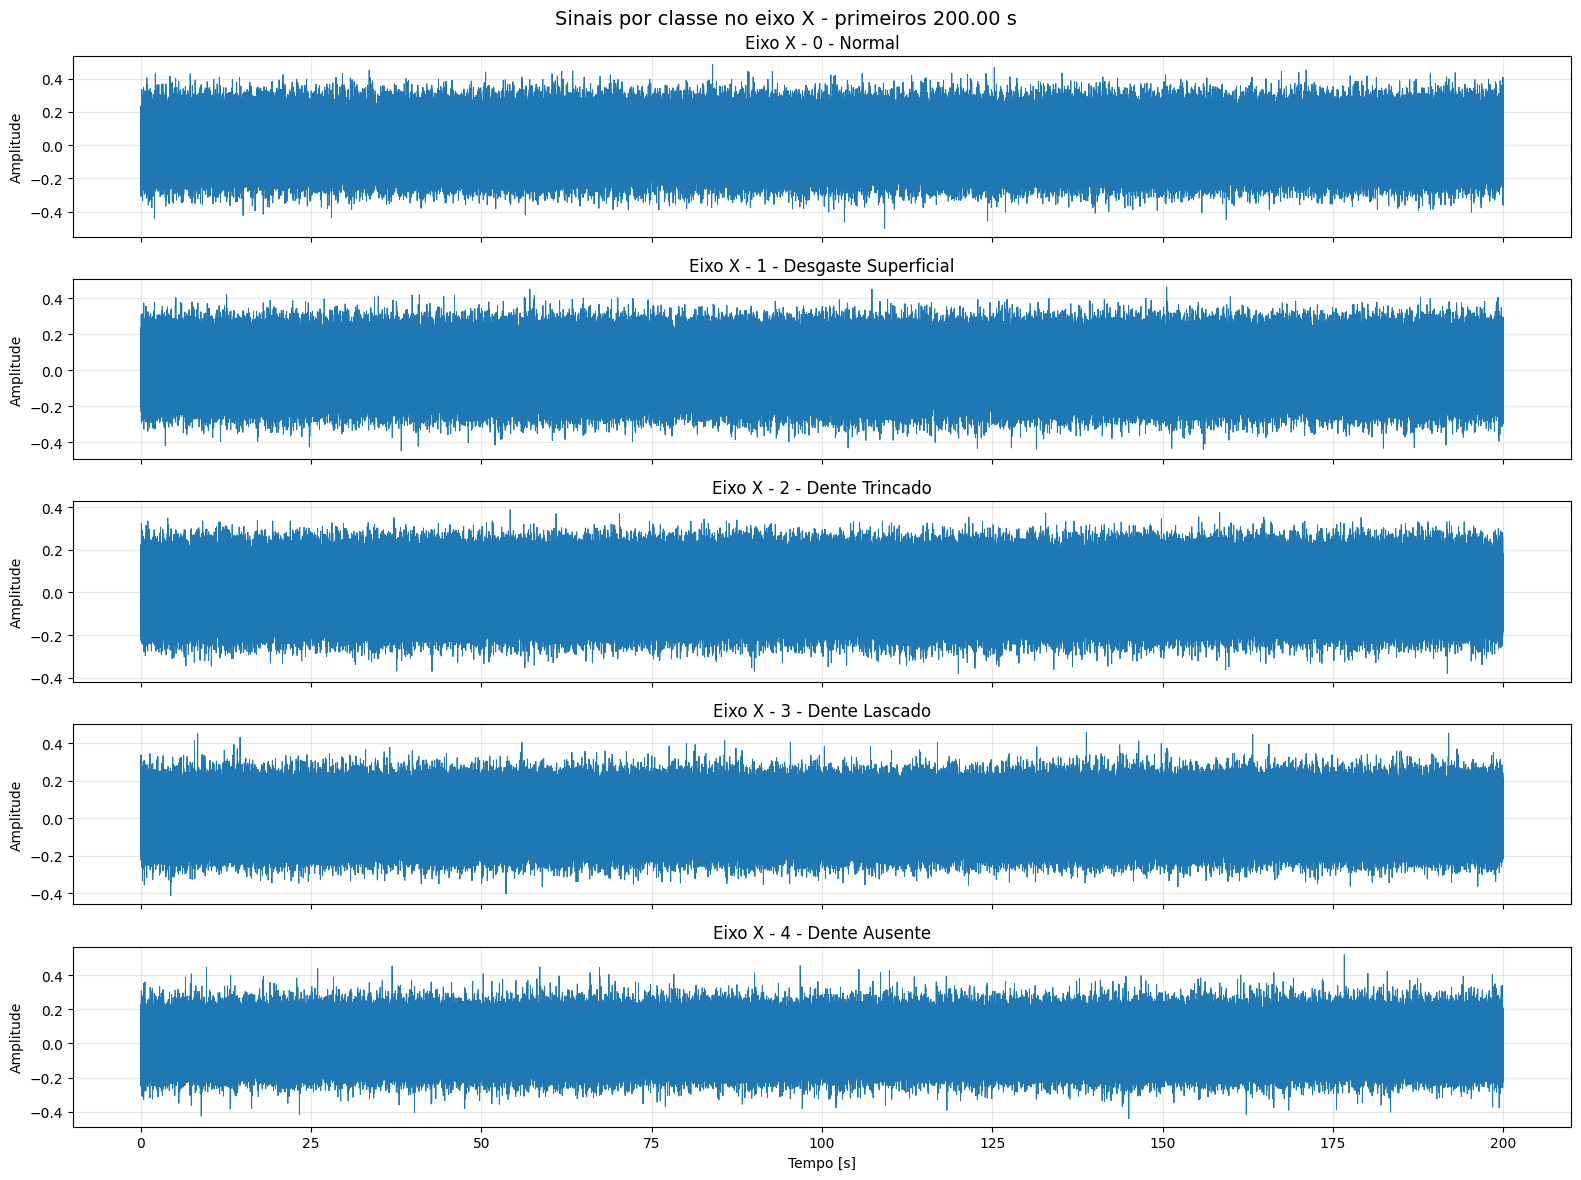

In [331]:
eixo_para_plot = "x"  # escolha entre "x", "y" ou "z"
duracao_plot_s = 200.0   # use None para plotar todo o sinal reconstruido da classe

classes_por_eixo = {
    "x": [df_vibracao_eixo_x_classe0, df_vibracao_eixo_x_classe1, df_vibracao_eixo_x_classe2, df_vibracao_eixo_x_classe3, df_vibracao_eixo_x_classe4],
    "y": [df_vibracao_eixo_y_classe0, df_vibracao_eixo_y_classe1, df_vibracao_eixo_y_classe2, df_vibracao_eixo_y_classe3, df_vibracao_eixo_y_classe4],
    "z": [df_vibracao_eixo_z_classe0, df_vibracao_eixo_z_classe1, df_vibracao_eixo_z_classe2, df_vibracao_eixo_z_classe3, df_vibracao_eixo_z_classe4],
}

fig, axes = plt.subplots(5, 1, figsize=(16, 12), sharex=True)

for classe, ax in enumerate(axes):
    df_classe = classes_por_eixo[eixo_para_plot][classe].drop(columns="classe")
    sinal_classe = df_classe.to_numpy().reshape(-1)

    if duracao_plot_s is None:
        amostras_plot = sinal_classe.size
    else:
        amostras_plot = min(int(duracao_plot_s * fs), sinal_classe.size)

    tempo_plot = np.arange(amostras_plot) / fs
    ax.plot(tempo_plot, sinal_classe[:amostras_plot], linewidth=0.7)
    ax.set_title(f"Eixo {eixo_para_plot.upper()} - {rotulo_classe(classe)}")
    ax.set_ylabel("Amplitude")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Tempo [s]")

if duracao_plot_s is None:
    titulo_figura = f"Sinais por classe no eixo {eixo_para_plot.upper()} - duracao completa"
    sufixo_arquivo = "duracao_completa"
else:
    titulo_figura = f"Sinais por classe no eixo {eixo_para_plot.upper()} - primeiros {duracao_plot_s:.2f} s"
    sufixo_arquivo = f"{duracao_plot_s:.2f}s".replace(".", "_")

fig.suptitle(titulo_figura, fontsize=14)
plt.tight_layout()

pasta_imagens = Path("images")
pasta_imagens.mkdir(exist_ok=True)
caminho_imagem = pasta_imagens / f"sinais_por_classe_eixo_{eixo_para_plot}_{sufixo_arquivo}.png"
fig.savefig(caminho_imagem, dpi=300, bbox_inches="tight")
print(f"Gráfico salvo em: {caminho_imagem}")

plt.show()


In [332]:
duracao_intervalo_s = 1.0

linhas_por_intervalo_exato = duracao_intervalo_s / duracao_linha_s
linhas_por_intervalo = int(linhas_por_intervalo_exato)
amostras_por_intervalo = linhas_por_intervalo * pontos_por_linha

segmentos_eixo_x_classe0 = df_vibracao_eixo_x_classe0.drop(columns="classe").to_numpy().reshape(-1, amostras_por_intervalo)
segmentos_eixo_x_classe1 = df_vibracao_eixo_x_classe1.drop(columns="classe").to_numpy().reshape(-1, amostras_por_intervalo)
segmentos_eixo_x_classe2 = df_vibracao_eixo_x_classe2.drop(columns="classe").to_numpy().reshape(-1, amostras_por_intervalo)
segmentos_eixo_x_classe3 = df_vibracao_eixo_x_classe3.drop(columns="classe").to_numpy().reshape(-1, amostras_por_intervalo)
segmentos_eixo_x_classe4 = df_vibracao_eixo_x_classe4.drop(columns="classe").to_numpy().reshape(-1, amostras_por_intervalo)

segmentos_eixo_y_classe0 = df_vibracao_eixo_y_classe0.drop(columns="classe").to_numpy().reshape(-1, amostras_por_intervalo)
segmentos_eixo_y_classe1 = df_vibracao_eixo_y_classe1.drop(columns="classe").to_numpy().reshape(-1, amostras_por_intervalo)
segmentos_eixo_y_classe2 = df_vibracao_eixo_y_classe2.drop(columns="classe").to_numpy().reshape(-1, amostras_por_intervalo)
segmentos_eixo_y_classe3 = df_vibracao_eixo_y_classe3.drop(columns="classe").to_numpy().reshape(-1, amostras_por_intervalo)
segmentos_eixo_y_classe4 = df_vibracao_eixo_y_classe4.drop(columns="classe").to_numpy().reshape(-1, amostras_por_intervalo)

segmentos_eixo_z_classe0 = df_vibracao_eixo_z_classe0.drop(columns="classe").to_numpy().reshape(-1, amostras_por_intervalo)
segmentos_eixo_z_classe1 = df_vibracao_eixo_z_classe1.drop(columns="classe").to_numpy().reshape(-1, amostras_por_intervalo)
segmentos_eixo_z_classe2 = df_vibracao_eixo_z_classe2.drop(columns="classe").to_numpy().reshape(-1, amostras_por_intervalo)
segmentos_eixo_z_classe3 = df_vibracao_eixo_z_classe3.drop(columns="classe").to_numpy().reshape(-1, amostras_por_intervalo)
segmentos_eixo_z_classe4 = df_vibracao_eixo_z_classe4.drop(columns="classe").to_numpy().reshape(-1, amostras_por_intervalo)

segmentos_por_eixo_classe = {
    "x": {0: segmentos_eixo_x_classe0, 1: segmentos_eixo_x_classe1, 2: segmentos_eixo_x_classe2, 3: segmentos_eixo_x_classe3, 4: segmentos_eixo_x_classe4},
    "y": {0: segmentos_eixo_y_classe0, 1: segmentos_eixo_y_classe1, 2: segmentos_eixo_y_classe2, 3: segmentos_eixo_y_classe3, 4: segmentos_eixo_y_classe4},
    "z": {0: segmentos_eixo_z_classe0, 1: segmentos_eixo_z_classe1, 2: segmentos_eixo_z_classe2, 3: segmentos_eixo_z_classe3, 4: segmentos_eixo_z_classe4},
}

print(f"Duração do intervalo: {duracao_intervalo_s:.2f} s")
print(f"Linhas por intervalo: {linhas_por_intervalo}")
print(f"Amostras por intervalo: {amostras_por_intervalo}")

Duração do intervalo: 1.00 s
Linhas por intervalo: 50
Amostras por intervalo: 10000


In [333]:
resumo_segmentacao = pd.DataFrame({
    "eixo": ["x", "x", "x", "x", "x", "y", "y", "y", "y", "y", "z", "z", "z", "z", "z"],
    "classe": [0, 1, 2, 3, 4, 0, 1, 2, 3, 4, 0, 1, 2, 3, 4],
    "n_segmentos": [
        segmentos_eixo_x_classe0.shape[0], segmentos_eixo_x_classe1.shape[0], segmentos_eixo_x_classe2.shape[0], segmentos_eixo_x_classe3.shape[0], segmentos_eixo_x_classe4.shape[0],
        segmentos_eixo_y_classe0.shape[0], segmentos_eixo_y_classe1.shape[0], segmentos_eixo_y_classe2.shape[0], segmentos_eixo_y_classe3.shape[0], segmentos_eixo_y_classe4.shape[0],
        segmentos_eixo_z_classe0.shape[0], segmentos_eixo_z_classe1.shape[0], segmentos_eixo_z_classe2.shape[0], segmentos_eixo_z_classe3.shape[0], segmentos_eixo_z_classe4.shape[0],
    ],
    "amostras_por_segmento": [
        segmentos_eixo_x_classe0.shape[1], segmentos_eixo_x_classe1.shape[1], segmentos_eixo_x_classe2.shape[1], segmentos_eixo_x_classe3.shape[1], segmentos_eixo_x_classe4.shape[1],
        segmentos_eixo_y_classe0.shape[1], segmentos_eixo_y_classe1.shape[1], segmentos_eixo_y_classe2.shape[1], segmentos_eixo_y_classe3.shape[1], segmentos_eixo_y_classe4.shape[1],
        segmentos_eixo_z_classe0.shape[1], segmentos_eixo_z_classe1.shape[1], segmentos_eixo_z_classe2.shape[1], segmentos_eixo_z_classe3.shape[1], segmentos_eixo_z_classe4.shape[1],
    ],
})

resumo_segmentacao

,eixo,classe,n_segmentos,amostras_por_segmento
0,x,0,200,10000
1,x,1,200,10000
2,x,2,200,10000
3,x,3,200,10000
4,x,4,200,10000
5,y,0,200,10000
6,y,1,200,10000
7,y,2,200,10000
8,y,3,200,10000
9,y,4,200,10000


In [334]:
def FFT_multicanal(df, time_col='Tempo', value_cols=None,
                   aplicar_janela=True, janela='hann',
                   remover_dc=False, verificar_uniforme=True):
    """
    Calcula o espectro de amplitude (single-sided) para múltiplos sinais
    reais (colunas) em um DataFrame.

    Parâmetros
    ----------
    df : pd.DataFrame
        DataFrame contendo os dados.
    time_col : str, opcional
        Nome da coluna de tempo (padrão: 'Tempo').
    value_cols : list de str, ou None, opcional
        Lista com os nomes das colunas de valor a serem processadas.
        Se None (padrão), a função processará TODAS as colunas numéricas
        exceto a `time_col`.
    aplicar_janela : bool, opcional
        Se True, aplica uma função de janela aos sinais.
    janela : str, opcional
        Tipo de janela a ser aplicada. Opções: 'hann', 'hamming', 'blackman', 'flattop'.
    remover_dc : bool, opcional
        Se True, remove o componente de frequência zero (offset DC) do resultado.
    verificar_uniforme : bool, opcional
        Se True, verifica se a amostragem de tempo é uniforme.

    Retorna
    -------
    pd.DataFrame
        Um DataFrame contendo:
        - Uma coluna 'Frequencia'.
        - Uma coluna de 'Amplitude_[nome_da_coluna]' para cada sinal processado.

    Levanta
    -------
    ValueError
        Se `time_col` não for encontrada ou se a amostragem não for uniforme.
    """
    # --- 1. Validação e Preparação dos Dados ---
    if time_col not in df.columns:
        raise ValueError(f"A coluna de tempo '{time_col}' não foi encontrada no DataFrame.")

    t = pd.to_numeric(df[time_col], errors='coerce').to_numpy()


    if value_cols is None:
        value_cols = df.select_dtypes(include=np.number).columns.drop(time_col).tolist()
    elif isinstance(value_cols, str):
        value_cols = [value_cols]

    # --- 2. Preparação da FFT (cálculos comuns a todos os canais) ---
    mask_t = ~np.isnan(t)
    t = t[mask_t]

    N = t.size
    if N < 2:
        return pd.DataFrame({'Frequencia': []})

    dt_arr = np.diff(t)
    dt = dt_arr[0]
    if verificar_uniforme and not np.allclose(dt_arr, dt, rtol=1e-5, atol=1e-9):
        raise ValueError("A amostragem de tempo não é uniforme. Considere reamostrar os dados.")


    f = rfftfreq(N, d=dt)


    resultados_df = pd.DataFrame({'Frequencia': f})

    # --- 3. Loop para processar cada coluna de valor ---
    for col in value_cols:
        if col not in df.columns:
            print(f"Aviso: A coluna '{col}' não foi encontrada e será ignorada.")
            continue

        y = pd.to_numeric(df[col], errors='coerce').to_numpy()
        y = y[mask_t] # Aplica a mesma máscara do tempo

        # Ignora colunas que ficaram vazias após limpeza
        if y.size != N:
            print(f"Aviso: A coluna '{col}' tem tamanho inconsistente com o tempo e será ignorada.")
            continue

        yw = y.astype(float)

        if aplicar_janela:
            janelas_disponiveis = {
                'hann': signal.windows.hann, 'hamming': signal.windows.hamming,
                'blackman': signal.windows.blackman, 'flattop': signal.windows.flattop
            }
            w = janelas_disponiveis[janela](N)
            yw = yw * w
            norm_factor = w.sum()
        else:
            norm_factor = N

        Y = rfft(yw)

        mag = (2.0 / norm_factor) * np.abs(Y)
        mag[0] /= 2.0
        if N % 2 == 0:
            mag[-1] /= 2.0

        # Adiciona a amplitude calculada ao DataFrame de resultados
        resultados_df[f'Amplitude_{col}'] = mag

    # --- 4. Remoção do Componente DC ---
    if remover_dc:
        resultados_df = resultados_df.iloc[1:].reset_index(drop=True)

    return resultados_df

Grafico salvo em: images\fft_classica_sem_media_eixo_x_segmento_0_0_1000Hz.png


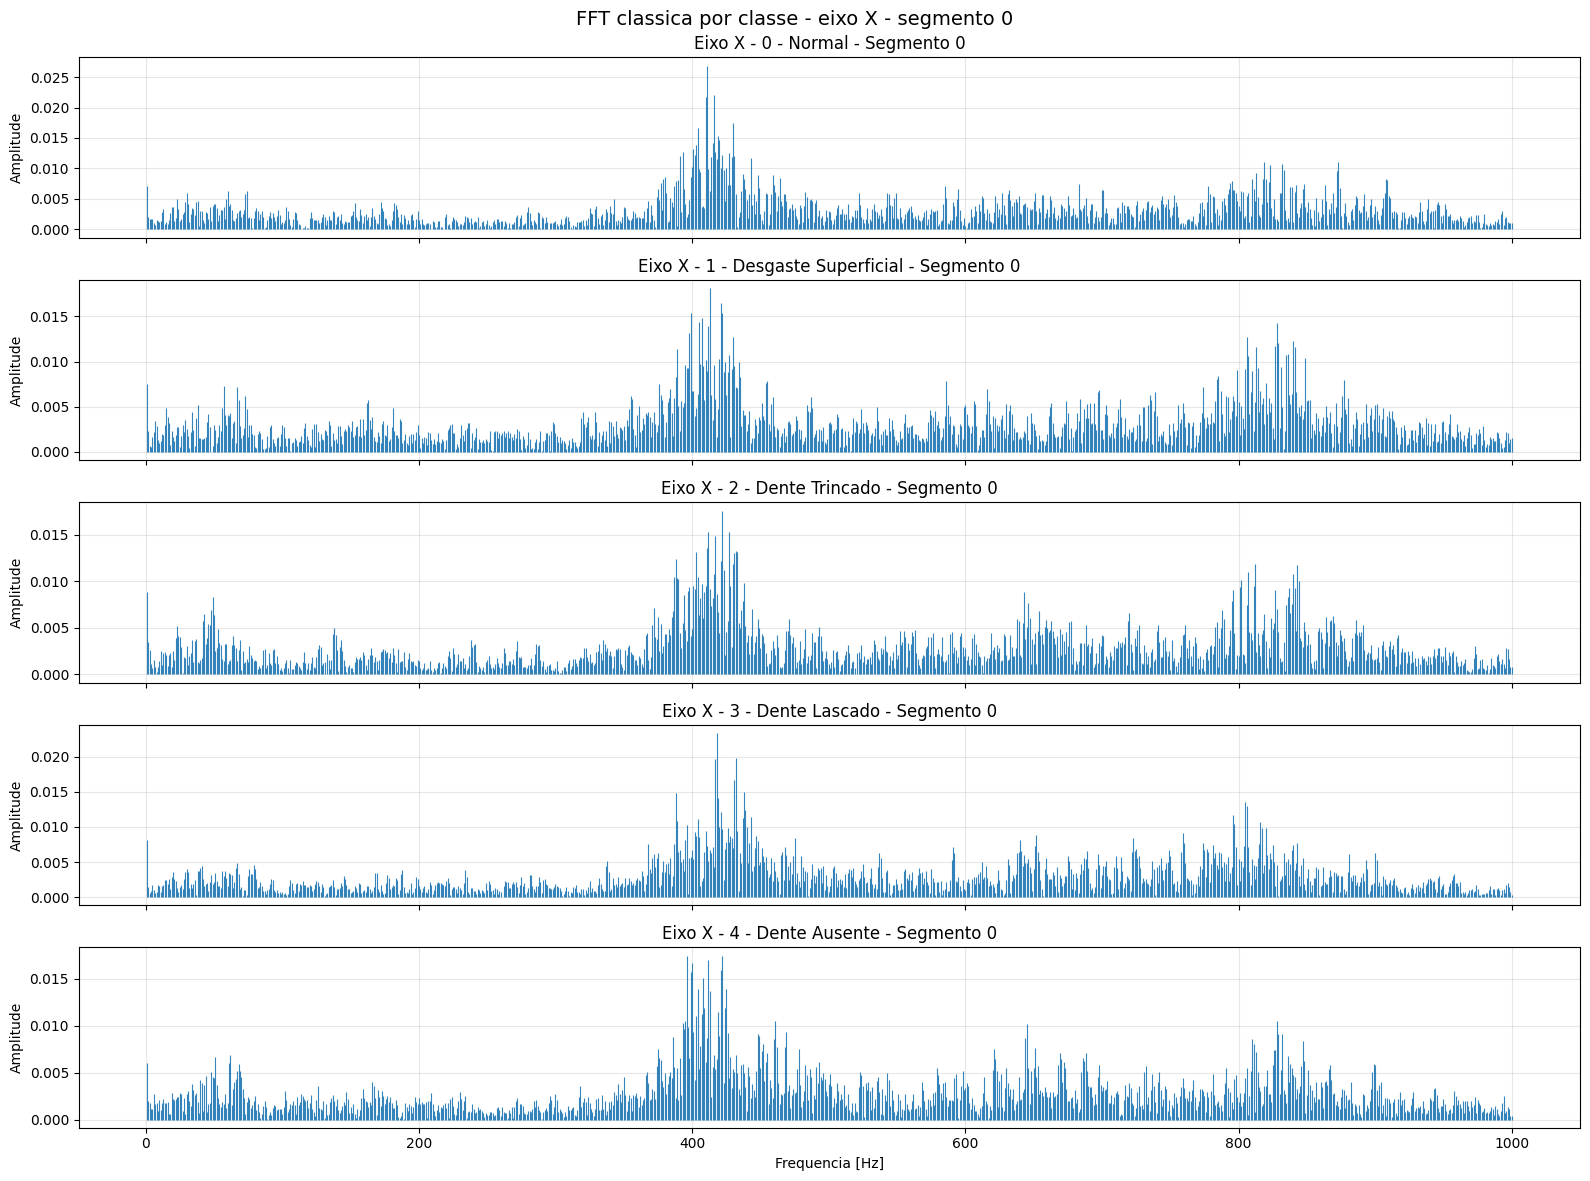

,classe,segmento,frequencia_pico_hz,amplitude_pico
0,0,0,411.0,0.026884
1,1,0,413.0,0.018127
2,2,0,422.0,0.017621
3,3,0,418.0,0.023414
4,4,0,396.0,0.017496


In [335]:
eixo_fft_plot = "x"
segmento_fft_plot = 0
frequencia_max_hz = 1000
cor_fft = "tab:blue"

tempo_intervalo = np.arange(amostras_por_intervalo) / fs

segmentos_classes_eixo = {
    "x": [segmentos_eixo_x_classe0, segmentos_eixo_x_classe1, segmentos_eixo_x_classe2, segmentos_eixo_x_classe3, segmentos_eixo_x_classe4],
    "y": [segmentos_eixo_y_classe0, segmentos_eixo_y_classe1, segmentos_eixo_y_classe2, segmentos_eixo_y_classe3, segmentos_eixo_y_classe4],
    "z": [segmentos_eixo_z_classe0, segmentos_eixo_z_classe1, segmentos_eixo_z_classe2, segmentos_eixo_z_classe3, segmentos_eixo_z_classe4],
}

fft_por_classe = {}
picos_fft_segmento = []

for classe, segmentos_classe in enumerate(segmentos_classes_eixo[eixo_fft_plot]):
    if segmento_fft_plot >= segmentos_classe.shape[0]:
        raise ValueError(f"O segmento {segmento_fft_plot} nao existe para a classe {classe}.")

    df_fft_entrada = pd.DataFrame({
        "Tempo": tempo_intervalo,
        "Segmento": segmentos_classe[segmento_fft_plot],
    })

    fft_classe = FFT_multicanal(
        df_fft_entrada,
        time_col="Tempo",
        value_cols="Segmento",
        aplicar_janela=True,
        janela="hann",
        remover_dc=True,
    )

    fft_classe = fft_classe.rename(columns={"Amplitude_Segmento": "Amplitude_para_plot"})
    fft_por_classe[classe] = fft_classe[["Frequencia", "Amplitude_para_plot"]].copy()

    indice_pico = fft_classe["Amplitude_para_plot"].idxmax()
    picos_fft_segmento.append({
        "classe": classe,
        "segmento": segmento_fft_plot,
        "frequencia_pico_hz": fft_classe.loc[indice_pico, "Frequencia"],
        "amplitude_pico": fft_classe.loc[indice_pico, "Amplitude_para_plot"],
    })

fig, axes = plt.subplots(5, 1, figsize=(16, 12), sharex=True)

for classe, ax in enumerate(axes):
    fft_classe = fft_por_classe[classe]
    mascara_freq = fft_classe["Frequencia"] <= frequencia_max_hz
    frequencias_plot = fft_classe.loc[mascara_freq, "Frequencia"].to_numpy()
    amplitudes_plot = fft_classe.loc[mascara_freq, "Amplitude_para_plot"].to_numpy()

    marcador, hastes, base = ax.stem(frequencias_plot, amplitudes_plot, linefmt=cor_fft, markerfmt=" ", basefmt=" ")
    plt.setp(hastes, linewidth=0.8, alpha=0.9)
    ax.set_title(f"Eixo {eixo_fft_plot.upper()} - {rotulo_classe(classe)} - Segmento {segmento_fft_plot}")
    ax.set_ylabel("Amplitude")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Frequencia [Hz]")
fig.suptitle(f"FFT classica por classe - eixo {eixo_fft_plot.upper()} - segmento {segmento_fft_plot}", fontsize=14)

pasta_imagens = Path("images")
pasta_imagens.mkdir(exist_ok=True)
caminho_imagem_fft = pasta_imagens / f"fft_classica_sem_media_eixo_{eixo_fft_plot}_segmento_{segmento_fft_plot}_0_{int(frequencia_max_hz)}Hz.png"
fig.savefig(caminho_imagem_fft, dpi=300, bbox_inches="tight")
print(f"Grafico salvo em: {caminho_imagem_fft}")

plt.tight_layout()
plt.show()

picos_fft_segmento = pd.DataFrame(picos_fft_segmento)
picos_fft_segmento


In [336]:
bandas_frequencia_hz = [(0, 50), (50, 150), (150, 300), (300, 600), (600, 1200), (1200, 2500), (2500, 5000)]

segmentos_por_eixo = {
    "x": [segmentos_eixo_x_classe0, segmentos_eixo_x_classe1, segmentos_eixo_x_classe2, segmentos_eixo_x_classe3, segmentos_eixo_x_classe4],
    "y": [segmentos_eixo_y_classe0, segmentos_eixo_y_classe1, segmentos_eixo_y_classe2, segmentos_eixo_y_classe3, segmentos_eixo_y_classe4],
    "z": [segmentos_eixo_z_classe0, segmentos_eixo_z_classe1, segmentos_eixo_z_classe2, segmentos_eixo_z_classe3, segmentos_eixo_z_classe4],
}

linhas_features = []

for classe in range(5):
    segmentos_x = segmentos_por_eixo["x"][classe]
    segmentos_y = segmentos_por_eixo["y"][classe]
    segmentos_z = segmentos_por_eixo["z"][classe]

    for segmento_id in range(segmentos_x.shape[0]):
        linha = {
            "classe": classe,
            "segmento_id": segmento_id,
            "tempo_inicial_s": segmento_id * duracao_intervalo_s,
            "tempo_final_s": (segmento_id + 1) * duracao_intervalo_s,
        }

        segmentos_atuais = {
            "x": segmentos_x[segmento_id],
            "y": segmentos_y[segmento_id],
            "z": segmentos_z[segmento_id],
        }

        for eixo, sinal in segmentos_atuais.items():
            media = np.mean(sinal)
            desvio_padrao = np.std(sinal)
            rms = np.sqrt(np.mean(sinal ** 2))
            media_absoluta = np.mean(np.abs(sinal))
            pico_maximo = np.max(sinal)
            pico_minimo = np.min(sinal)
            pico_a_pico = pico_maximo - pico_minimo
            fator_crista = np.max(np.abs(sinal)) / rms if rms != 0 else 0.0

            sinal_centrado = sinal - media
            frequencias = np.fft.rfftfreq(sinal_centrado.size, d=1 / fs)
            amplitudes = np.abs(np.fft.rfft(sinal_centrado)) / sinal_centrado.size
            amplitudes[1:-1] = 2 * amplitudes[1:-1]

            frequencias_sem_dc = frequencias[1:]
            amplitudes_sem_dc = amplitudes[1:]
            potencias_sem_dc = amplitudes_sem_dc ** 2

            indice_pico = np.argmax(amplitudes_sem_dc)
            frequencia_dominante = frequencias_sem_dc[indice_pico]
            amplitude_dominante = amplitudes_sem_dc[indice_pico]
            energia_total_fft = np.sum(potencias_sem_dc)

            soma_amplitudes = np.sum(amplitudes_sem_dc)
            centroide_espectral = np.sum(frequencias_sem_dc * amplitudes_sem_dc) / soma_amplitudes if soma_amplitudes != 0 else 0.0
            largura_banda_espectral = np.sqrt(np.sum(((frequencias_sem_dc - centroide_espectral) ** 2) * amplitudes_sem_dc) / soma_amplitudes) if soma_amplitudes != 0 else 0.0

            linha[f"media_{eixo}"] = media
            linha[f"desvio_padrao_{eixo}"] = desvio_padrao
            linha[f"rms_{eixo}"] = rms
            linha[f"media_absoluta_{eixo}"] = media_absoluta
            linha[f"pico_maximo_{eixo}"] = pico_maximo
            linha[f"pico_minimo_{eixo}"] = pico_minimo
            linha[f"pico_a_pico_{eixo}"] = pico_a_pico
            linha[f"fator_crista_{eixo}"] = fator_crista
            linha[f"frequencia_dominante_{eixo}"] = frequencia_dominante
            linha[f"amplitude_dominante_{eixo}"] = amplitude_dominante
            linha[f"energia_total_fft_{eixo}"] = energia_total_fft
            linha[f"centroide_espectral_{eixo}"] = centroide_espectral
            linha[f"largura_banda_espectral_{eixo}"] = largura_banda_espectral

            for inicio_hz, fim_hz in bandas_frequencia_hz:
                mascara_banda = (frequencias_sem_dc >= inicio_hz) & (frequencias_sem_dc < fim_hz)
                energia_banda = np.sum(potencias_sem_dc[mascara_banda])
                energia_relativa_banda = energia_banda / energia_total_fft if energia_total_fft != 0 else 0.0
                linha[f"energia_{inicio_hz}_{fim_hz}Hz_{eixo}"] = energia_banda
                linha[f"energia_relativa_{inicio_hz}_{fim_hz}Hz_{eixo}"] = energia_relativa_banda

        linha["relacao_rms_x_y"] = linha["rms_x"] / linha["rms_y"] if linha["rms_y"] != 0 else 0.0
        linha["relacao_rms_x_z"] = linha["rms_x"] / linha["rms_z"] if linha["rms_z"] != 0 else 0.0
        linha["relacao_rms_y_z"] = linha["rms_y"] / linha["rms_z"] if linha["rms_z"] != 0 else 0.0
        linha["delta_freq_dominante_x_y"] = abs(linha["frequencia_dominante_x"] - linha["frequencia_dominante_y"])
        linha["delta_freq_dominante_x_z"] = abs(linha["frequencia_dominante_x"] - linha["frequencia_dominante_z"])
        linha["delta_freq_dominante_y_z"] = abs(linha["frequencia_dominante_y"] - linha["frequencia_dominante_z"])

        linhas_features.append(linha)

features_modelo = pd.DataFrame(linhas_features).round(6)
features_modelo.head()


,classe,segmento_id,tempo_inicial_s,tempo_final_s,media_x,desvio_padrao_x,rms_x,media_absoluta_x,pico_maximo_x,pico_minimo_x,...,energia_1200_2500Hz_z,energia_relativa_1200_2500Hz_z,energia_2500_5000Hz_z,energia_relativa_2500_5000Hz_z,relacao_rms_x_y,relacao_rms_x_z,relacao_rms_y_z,delta_freq_dominante_x_y,delta_freq_dominante_x_z,delta_freq_dominante_y_z
0,0,0,0.0,1.0,0.008540,0.093229,0.093619,0.073908,0.404441,-0.334140,...,0.055420,0.430351,0.011623,0.090256,0.470379,0.368668,0.783767,729.0,5.0,724.0
1,0,1,1.0,2.0,0.007922,0.091795,0.092136,0.072919,0.341273,-0.376662,...,0.057920,0.434858,0.011678,0.087678,0.456643,0.356754,0.781253,686.0,1280.0,594.0
2,0,2,2.0,3.0,0.009067,0.092095,0.092540,0.073664,0.431305,-0.439837,...,0.050817,0.408582,0.011677,0.093890,0.469764,0.370745,0.789215,846.0,0.0,846.0
3,0,3,3.0,4.0,0.009319,0.093702,0.094165,0.074588,0.367715,-0.367699,...,0.051028,0.410672,0.011127,0.089550,0.473810,0.377490,0.796712,749.0,8.0,741.0
4,0,4,4.0,5.0,0.008655,0.092763,0.093166,0.074004,0.413657,-0.351957,...,0.053400,0.415114,0.011879,0.092344,0.467444,0.367019,0.785160,0.0,27.0,27.0


In [337]:
colunas_identificacao = ["classe", "segmento_id", "tempo_inicial_s", "tempo_final_s"]
X_features = features_modelo.drop(columns=colunas_identificacao)
y_features = features_modelo["classe"].copy()

print(f"Formato da matriz de features: {X_features.shape}")
print(f"Formato do vetor de rótulos: {y_features.shape}")
print()
print("Distribuição das classes:")
print(y_features.value_counts().sort_index())

pd.concat([features_modelo[colunas_identificacao], X_features.iloc[:, :12]], axis=1).head()


Formato da matriz de features: (1000, 87)
Formato do vetor de rótulos: (1000,)

Distribuição das classes:
classe
0    200
1    200
2    200
3    200
4    200
Name: count, dtype: int64


,classe,segmento_id,tempo_inicial_s,tempo_final_s,media_x,desvio_padrao_x,rms_x,media_absoluta_x,pico_maximo_x,pico_minimo_x,pico_a_pico_x,fator_crista_x,frequencia_dominante_x,amplitude_dominante_x,energia_total_fft_x,centroide_espectral_x
0,0,0,0.0,1.0,0.008540,0.093229,0.093619,0.073908,0.404441,-0.334140,0.738581,4.320080,411.0,0.019406,0.017383,1732.227779
1,0,1,1.0,2.0,0.007922,0.091795,0.092136,0.072919,0.341273,-0.376662,0.717935,4.088110,423.0,0.017617,0.016852,1716.556572
2,0,2,2.0,3.0,0.009067,0.092095,0.092540,0.073664,0.431305,-0.439837,0.871142,4.752937,436.0,0.018289,0.016963,1711.967807
3,0,3,3.0,4.0,0.009319,0.093702,0.094165,0.074588,0.367715,-0.367699,0.735414,3.905021,401.0,0.015758,0.017560,1686.999114
4,0,4,4.0,5.0,0.008655,0.092763,0.093166,0.074004,0.413657,-0.351957,0.765614,4.440009,397.0,0.021734,0.017210,1715.950993


In [338]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay, roc_curve, auc
from xgboost import XGBClassifier
import shap


In [339]:
amostras_explicacao_por_classe = 3

indices_explicacao = (
    features_modelo.groupby("classe", group_keys=False)
    .sample(n=amostras_explicacao_por_classe, random_state=42)
    .index
    .sort_values()
)

amostras_explicacao_info = features_modelo.loc[indices_explicacao, colunas_identificacao].copy()
amostras_explicacao_info = amostras_explicacao_info.reset_index().rename(columns={"index": "indice_original"})
amostras_explicacao_info["classe_nome"] = amostras_explicacao_info["classe"].map(mapa_classes)
amostras_explicacao_info = amostras_explicacao_info.sort_values(["classe", "segmento_id"]).reset_index(drop=True)
indices_explicacao_ordenados = amostras_explicacao_info["indice_original"].to_list()

X_explicacao = X_features.loc[indices_explicacao_ordenados].copy().reset_index(drop=True)
y_explicacao = y_features.loc[indices_explicacao_ordenados].copy().reset_index(drop=True)

X_restante = X_features.drop(index=indices_explicacao_ordenados)
y_restante = y_features.drop(index=indices_explicacao_ordenados)

X_train, X_test, y_train, y_test = train_test_split(
    X_restante,
    y_restante,
    test_size=0.3,
    random_state=42,
    stratify=y_restante,
)

classes_roc = np.array([0, 1, 2, 3, 4])
y_test_bin = label_binarize(y_test, classes=classes_roc)

random_forest = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=1,
)
random_forest.fit(X_train, y_train)
y_pred_rf = random_forest.predict(X_test)
y_proba_rf = random_forest.predict_proba(X_test)

xgboost_model = XGBClassifier(
    objective="multi:softprob",
    num_class=5,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=1,
)
xgboost_model.fit(X_train, y_train)
y_pred_xgb = xgboost_model.predict(X_test)
y_proba_xgb = xgboost_model.predict_proba(X_test)

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(C=10, kernel="rbf", gamma="scale", probability=True, random_state=42)),
])
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
y_proba_svm = svm_model.predict_proba(X_test)

metricas_random_forest = pd.DataFrame([{
    "modelo": "RandomForest",
    "accuracy": accuracy_score(y_test, y_pred_rf),
    "precision_macro": precision_score(y_test, y_pred_rf, average="macro"),
    "recall_macro": recall_score(y_test, y_pred_rf, average="macro"),
    "f1_macro": f1_score(y_test, y_pred_rf, average="macro"),
}])

metricas_xgboost = pd.DataFrame([{
    "modelo": "XGBoost",
    "accuracy": accuracy_score(y_test, y_pred_xgb),
    "precision_macro": precision_score(y_test, y_pred_xgb, average="macro"),
    "recall_macro": recall_score(y_test, y_pred_xgb, average="macro"),
    "f1_macro": f1_score(y_test, y_pred_xgb, average="macro"),
}])

metricas_svm = pd.DataFrame([{
    "modelo": "SVM",
    "accuracy": accuracy_score(y_test, y_pred_svm),
    "precision_macro": precision_score(y_test, y_pred_svm, average="macro"),
    "recall_macro": recall_score(y_test, y_pred_svm, average="macro"),
    "f1_macro": f1_score(y_test, y_pred_svm, average="macro"),
}])

comparacao_modelos = pd.concat([metricas_random_forest, metricas_xgboost, metricas_svm], ignore_index=True)

print("Amostras reservadas para explicabilidade:")
print(amostras_explicacao_info.to_string(index=False))
print()
print(f"Tamanho treino: {X_train.shape}")
print(f"Tamanho teste: {X_test.shape}")
print(f"Tamanho explicacao: {X_explicacao.shape}")
comparacao_modelos


Amostras reservadas para explicabilidade:
 indice_original  classe  segmento_id  tempo_inicial_s  tempo_final_s          classe_nome
              15       0           15             15.0           16.0               Normal
              30       0           30             30.0           31.0               Normal
              95       0           95             95.0           96.0               Normal
             233       1           33             33.0           34.0 Desgaste Superficial
             321       1          121            121.0          122.0 Desgaste Superficial
             376       1          176            176.0          177.0 Desgaste Superficial
             414       2           14             14.0           15.0       Dente Trincado
             509       2          109            109.0          110.0       Dente Trincado
             560       2          160            160.0          161.0       Dente Trincado
             663       3           63           

,modelo,accuracy,precision_macro,recall_macro,f1_macro
0,RandomForest,1.000000,1.000000,1.00000,1.00000
1,XGBoost,0.996622,0.996667,0.99661,0.99661
2,SVM,1.000000,1.000000,1.00000,1.00000


Metricas - RandomForest
      modelo  accuracy  precision_macro  recall_macro  f1_macro
RandomForest       1.0              1.0           1.0       1.0
                      precision    recall  f1-score   support

              Normal       1.00      1.00      1.00        59
Desgaste Superficial       1.00      1.00      1.00        59
      Dente Trincado       1.00      1.00      1.00        59
       Dente Lascado       1.00      1.00      1.00        60
       Dente Ausente       1.00      1.00      1.00        59

            accuracy                           1.00       296
           macro avg       1.00      1.00      1.00       296
        weighted avg       1.00      1.00      1.00       296

Grafico salvo em: images\avaliacao_randomforest.png


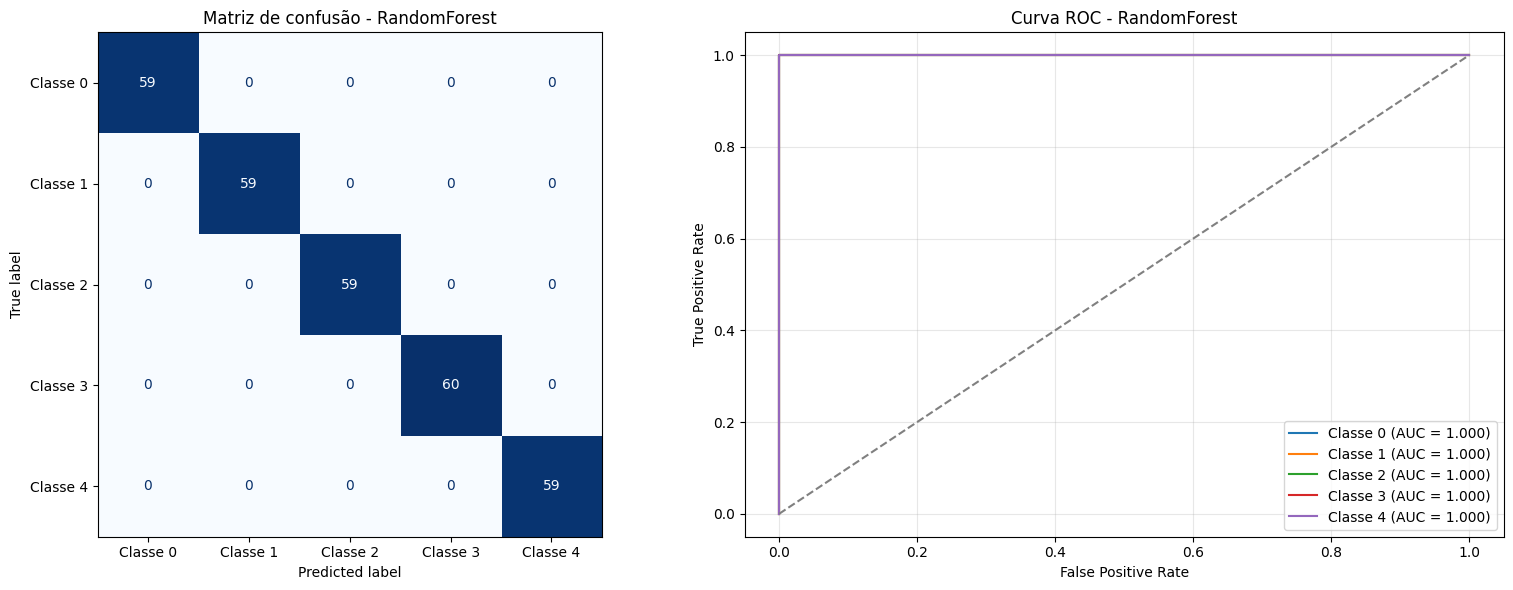

In [340]:
print("Metricas - RandomForest")
print(metricas_random_forest.to_string(index=False))
print(classification_report(y_test, y_pred_rf, labels=sorted(mapa_classes), target_names=nomes_classes_ordenados))

fpr_rf_0, tpr_rf_0, _ = roc_curve(y_test_bin[:, 0], y_proba_rf[:, 0])
fpr_rf_1, tpr_rf_1, _ = roc_curve(y_test_bin[:, 1], y_proba_rf[:, 1])
fpr_rf_2, tpr_rf_2, _ = roc_curve(y_test_bin[:, 2], y_proba_rf[:, 2])
fpr_rf_3, tpr_rf_3, _ = roc_curve(y_test_bin[:, 3], y_proba_rf[:, 3])
fpr_rf_4, tpr_rf_4, _ = roc_curve(y_test_bin[:, 4], y_proba_rf[:, 4])

auc_rf_0 = auc(fpr_rf_0, tpr_rf_0)
auc_rf_1 = auc(fpr_rf_1, tpr_rf_1)
auc_rf_2 = auc(fpr_rf_2, tpr_rf_2)
auc_rf_3 = auc(fpr_rf_3, tpr_rf_3)
auc_rf_4 = auc(fpr_rf_4, tpr_rf_4)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[0], cmap="Blues", colorbar=False, display_labels=labels_classes_curtas)
axes[0].set_title("Matriz de confusão - RandomForest")

axes[1].plot(fpr_rf_0, tpr_rf_0, linewidth=1.5, label=f"Classe 0 (AUC = {auc_rf_0:.3f})")
axes[1].plot(fpr_rf_1, tpr_rf_1, linewidth=1.5, label=f"Classe 1 (AUC = {auc_rf_1:.3f})")
axes[1].plot(fpr_rf_2, tpr_rf_2, linewidth=1.5, label=f"Classe 2 (AUC = {auc_rf_2:.3f})")
axes[1].plot(fpr_rf_3, tpr_rf_3, linewidth=1.5, label=f"Classe 3 (AUC = {auc_rf_3:.3f})")
axes[1].plot(fpr_rf_4, tpr_rf_4, linewidth=1.5, label=f"Classe 4 (AUC = {auc_rf_4:.3f})")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_title("Curva ROC - RandomForest")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
pasta_imagens = Path("images")
pasta_imagens.mkdir(exist_ok=True)
caminho_random_forest = pasta_imagens / "avaliacao_randomforest.png"
fig.savefig(caminho_random_forest, dpi=300, bbox_inches="tight")
print(f"Grafico salvo em: {caminho_random_forest}")
plt.show()


Metricas - XGBoost
 modelo  accuracy  precision_macro  recall_macro  f1_macro
XGBoost  0.996622         0.996667       0.99661   0.99661
                      precision    recall  f1-score   support

              Normal       0.98      1.00      0.99        59
Desgaste Superficial       1.00      0.98      0.99        59
      Dente Trincado       1.00      1.00      1.00        59
       Dente Lascado       1.00      1.00      1.00        60
       Dente Ausente       1.00      1.00      1.00        59

            accuracy                           1.00       296
           macro avg       1.00      1.00      1.00       296
        weighted avg       1.00      1.00      1.00       296

Grafico salvo em: images\avaliacao_xgboost.png


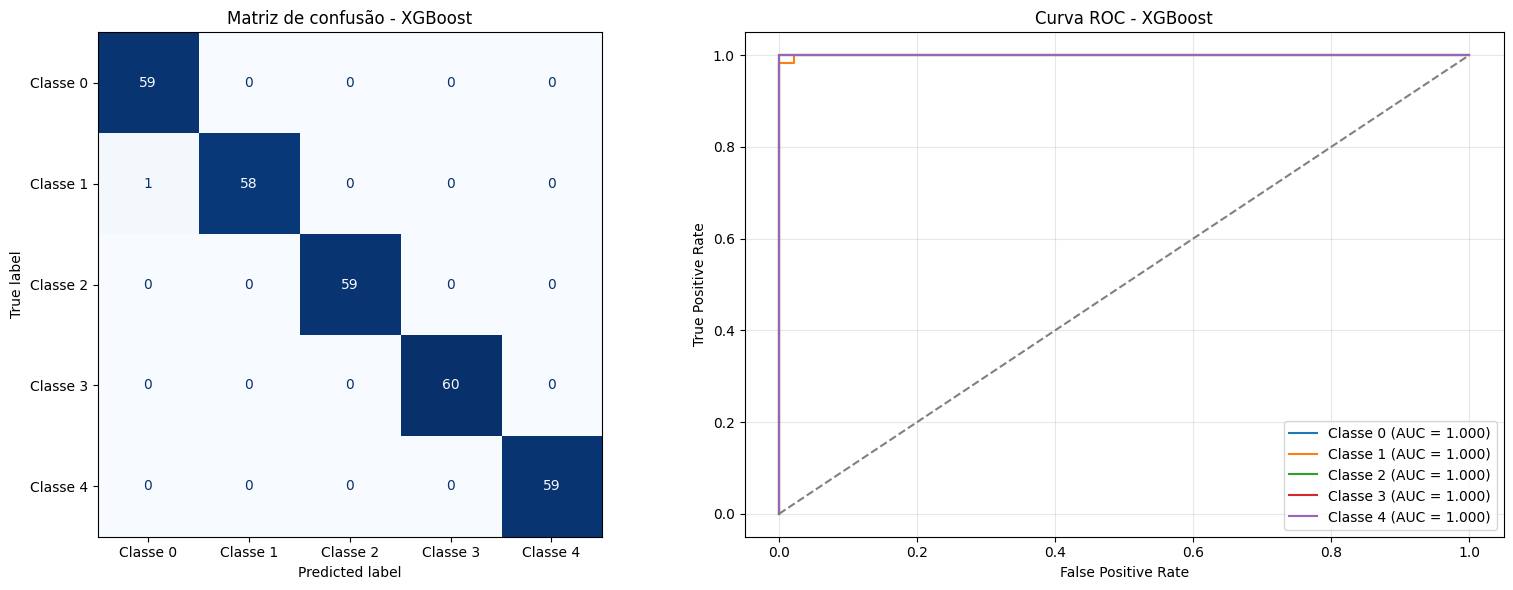

In [341]:
print("Metricas - XGBoost")
print(metricas_xgboost.to_string(index=False))
print(classification_report(y_test, y_pred_xgb, labels=sorted(mapa_classes), target_names=nomes_classes_ordenados))

fpr_xgb_0, tpr_xgb_0, _ = roc_curve(y_test_bin[:, 0], y_proba_xgb[:, 0])
fpr_xgb_1, tpr_xgb_1, _ = roc_curve(y_test_bin[:, 1], y_proba_xgb[:, 1])
fpr_xgb_2, tpr_xgb_2, _ = roc_curve(y_test_bin[:, 2], y_proba_xgb[:, 2])
fpr_xgb_3, tpr_xgb_3, _ = roc_curve(y_test_bin[:, 3], y_proba_xgb[:, 3])
fpr_xgb_4, tpr_xgb_4, _ = roc_curve(y_test_bin[:, 4], y_proba_xgb[:, 4])

auc_xgb_0 = auc(fpr_xgb_0, tpr_xgb_0)
auc_xgb_1 = auc(fpr_xgb_1, tpr_xgb_1)
auc_xgb_2 = auc(fpr_xgb_2, tpr_xgb_2)
auc_xgb_3 = auc(fpr_xgb_3, tpr_xgb_3)
auc_xgb_4 = auc(fpr_xgb_4, tpr_xgb_4)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, ax=axes[0], cmap="Blues", colorbar=False, display_labels=labels_classes_curtas)
axes[0].set_title("Matriz de confusão - XGBoost")

axes[1].plot(fpr_xgb_0, tpr_xgb_0, linewidth=1.5, label=f"Classe 0 (AUC = {auc_xgb_0:.3f})")
axes[1].plot(fpr_xgb_1, tpr_xgb_1, linewidth=1.5, label=f"Classe 1 (AUC = {auc_xgb_1:.3f})")
axes[1].plot(fpr_xgb_2, tpr_xgb_2, linewidth=1.5, label=f"Classe 2 (AUC = {auc_xgb_2:.3f})")
axes[1].plot(fpr_xgb_3, tpr_xgb_3, linewidth=1.5, label=f"Classe 3 (AUC = {auc_xgb_3:.3f})")
axes[1].plot(fpr_xgb_4, tpr_xgb_4, linewidth=1.5, label=f"Classe 4 (AUC = {auc_xgb_4:.3f})")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_title("Curva ROC - XGBoost")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
pasta_imagens = Path("images")
pasta_imagens.mkdir(exist_ok=True)
caminho_xgboost = pasta_imagens / "avaliacao_xgboost.png"
fig.savefig(caminho_xgboost, dpi=300, bbox_inches="tight")
print(f"Grafico salvo em: {caminho_xgboost}")
plt.show()


Metricas - SVM
modelo  accuracy  precision_macro  recall_macro  f1_macro
   SVM       1.0              1.0           1.0       1.0
                      precision    recall  f1-score   support

              Normal       1.00      1.00      1.00        59
Desgaste Superficial       1.00      1.00      1.00        59
      Dente Trincado       1.00      1.00      1.00        59
       Dente Lascado       1.00      1.00      1.00        60
       Dente Ausente       1.00      1.00      1.00        59

            accuracy                           1.00       296
           macro avg       1.00      1.00      1.00       296
        weighted avg       1.00      1.00      1.00       296

Grafico salvo em: images\avaliacao_svm.png


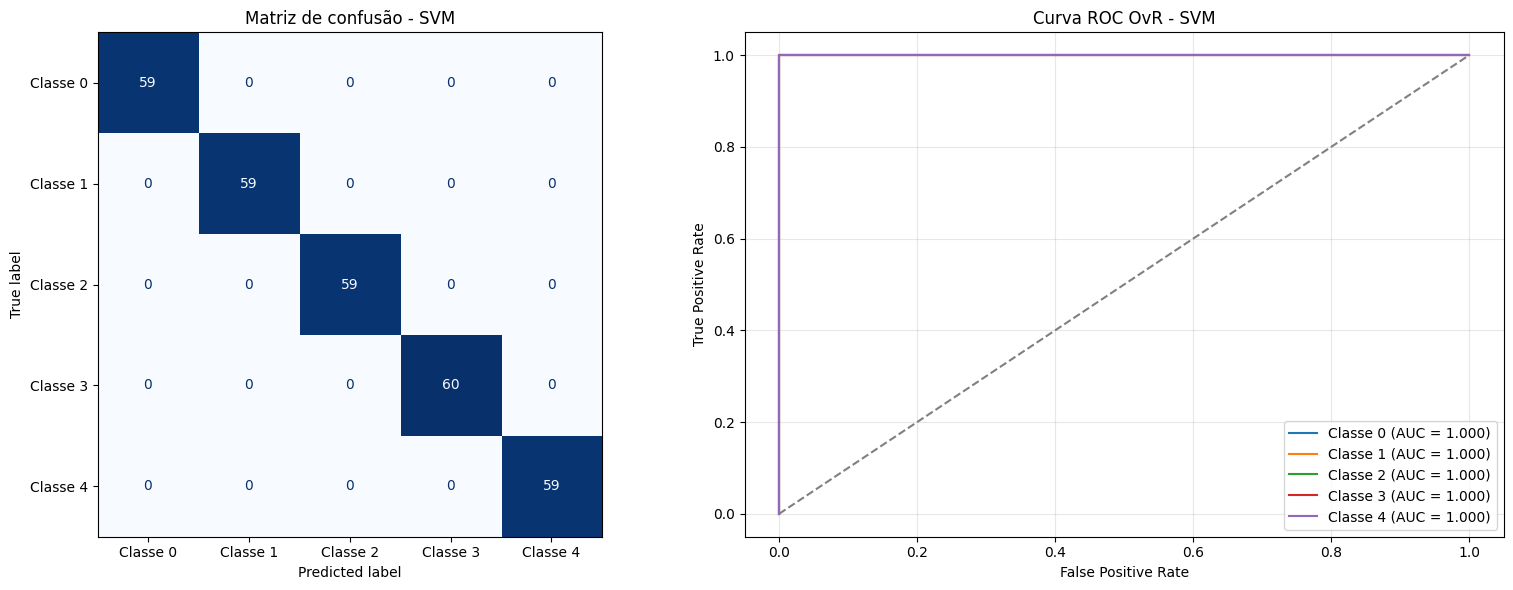

In [342]:
print("Metricas - SVM")
print(metricas_svm.to_string(index=False))
print(classification_report(y_test, y_pred_svm, labels=sorted(mapa_classes), target_names=nomes_classes_ordenados))

fpr_svm_0, tpr_svm_0, _ = roc_curve(y_test_bin[:, 0], y_proba_svm[:, 0])
fpr_svm_1, tpr_svm_1, _ = roc_curve(y_test_bin[:, 1], y_proba_svm[:, 1])
fpr_svm_2, tpr_svm_2, _ = roc_curve(y_test_bin[:, 2], y_proba_svm[:, 2])
fpr_svm_3, tpr_svm_3, _ = roc_curve(y_test_bin[:, 3], y_proba_svm[:, 3])
fpr_svm_4, tpr_svm_4, _ = roc_curve(y_test_bin[:, 4], y_proba_svm[:, 4])

auc_svm_0 = auc(fpr_svm_0, tpr_svm_0)
auc_svm_1 = auc(fpr_svm_1, tpr_svm_1)
auc_svm_2 = auc(fpr_svm_2, tpr_svm_2)
auc_svm_3 = auc(fpr_svm_3, tpr_svm_3)
auc_svm_4 = auc(fpr_svm_4, tpr_svm_4)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm, ax=axes[0], cmap="Blues", colorbar=False, display_labels=labels_classes_curtas)
axes[0].set_title("Matriz de confusão - SVM")

axes[1].plot(fpr_svm_0, tpr_svm_0, linewidth=1.5, label=f"Classe 0 (AUC = {auc_svm_0:.3f})")
axes[1].plot(fpr_svm_1, tpr_svm_1, linewidth=1.5, label=f"Classe 1 (AUC = {auc_svm_1:.3f})")
axes[1].plot(fpr_svm_2, tpr_svm_2, linewidth=1.5, label=f"Classe 2 (AUC = {auc_svm_2:.3f})")
axes[1].plot(fpr_svm_3, tpr_svm_3, linewidth=1.5, label=f"Classe 3 (AUC = {auc_svm_3:.3f})")
axes[1].plot(fpr_svm_4, tpr_svm_4, linewidth=1.5, label=f"Classe 4 (AUC = {auc_svm_4:.3f})")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_title("Curva ROC OvR - SVM")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
pasta_imagens = Path("images")
pasta_imagens.mkdir(exist_ok=True)
caminho_svm = pasta_imagens / "avaliacao_svm.png"
fig.savefig(caminho_svm, dpi=300, bbox_inches="tight")
print(f"Grafico salvo em: {caminho_svm}")
plt.show()


In [343]:
def organizar_shap_multiclasse(shap_values, n_classes):
    if hasattr(shap_values, "values"):
        shap_array = shap_values.values
    else:
        shap_array = shap_values

    if isinstance(shap_array, list):
        return np.stack(shap_array, axis=0)

    shap_array = np.asarray(shap_array)

    if shap_array.ndim == 3 and shap_array.shape[2] == n_classes:
        return np.moveaxis(shap_array, 2, 0)

    if shap_array.ndim == 3 and shap_array.shape[0] == n_classes:
        return shap_array

    raise ValueError(f"Formato de SHAP nao suportado: {shap_array.shape}")

def tabela_shap_local(modelo, X_ref, info_ref, nome_modelo, top_k=5):
    explainer = shap.TreeExplainer(modelo)
    shap_raw = explainer.shap_values(X_ref)
    shap_classes = organizar_shap_multiclasse(shap_raw, n_classes=len(classes_roc))
    predicoes = modelo.predict(X_ref)
    probabilidades = modelo.predict_proba(X_ref)

    linhas = []

    for i in range(X_ref.shape[0]):
        classe_predita = int(predicoes[i])
        valores_shap = shap_classes[classe_predita, i, :]
        ordem = np.argsort(np.abs(valores_shap))[::-1][:top_k]

        for posicao, indice_feature in enumerate(ordem, start=1):
            linhas.append({
                "modelo": nome_modelo,
                "amostra_explicacao": i,
                "classe_real": int(y_explicacao.iloc[i]),
                "classe_real_nome": mapa_classes[int(y_explicacao.iloc[i])],
                "classe_predita": classe_predita,
                "classe_predita_nome": mapa_classes[classe_predita],
                "probabilidade_predita": float(probabilidades[i, classe_predita]),
                "indice_original": int(info_ref.loc[i, "indice_original"]),
                "segmento_id": int(info_ref.loc[i, "segmento_id"]),
                "tempo_inicial_s": float(info_ref.loc[i, "tempo_inicial_s"]),
                "tempo_final_s": float(info_ref.loc[i, "tempo_final_s"]),
                "rank": posicao,
                "feature": X_ref.columns[indice_feature],
                "valor_feature": float(X_ref.iloc[i, indice_feature]),
                "shap_value": float(valores_shap[indice_feature]),
                "impacto_absoluto": float(abs(valores_shap[indice_feature])),
            })

    return pd.DataFrame(linhas)


Top features SHAP - RandomForest
      modelo  amostra_explicacao  classe_real     classe_real_nome  classe_predita  classe_predita_nome  probabilidade_predita  indice_original  segmento_id  tempo_inicial_s  tempo_final_s  rank                        feature  valor_feature  shap_value  impacto_absoluto
RandomForest                   0            0               Normal               0               Normal               0.993333               15           15             15.0           16.0     1          energia_2500_5000Hz_y       0.002481    0.050065          0.050065
RandomForest                   0            0               Normal               0               Normal               0.993333               15           15             15.0           16.0     2            energia_total_fft_x       0.017482    0.047430          0.047430
RandomForest                   0            0               Normal               0               Normal               0.993333               15           

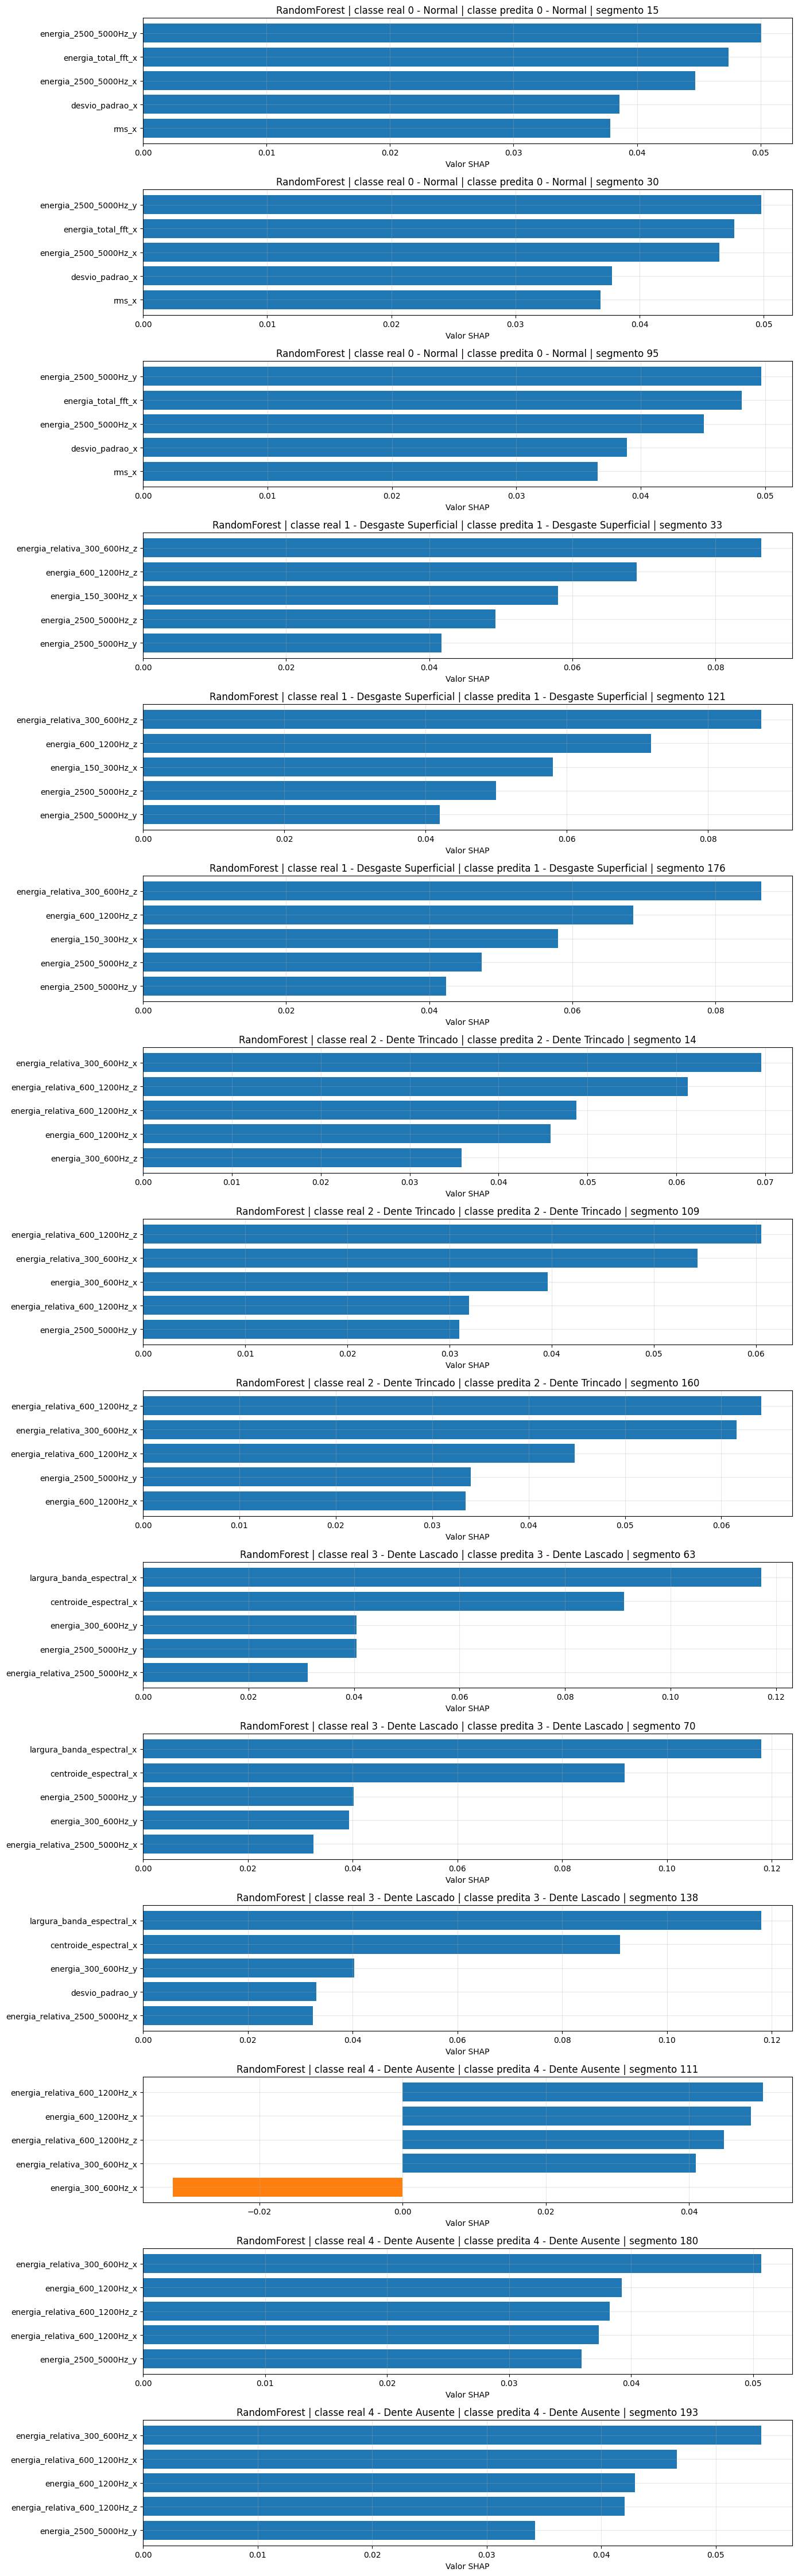

In [344]:
tabela_shap_rf = tabela_shap_local(random_forest, X_explicacao, amostras_explicacao_info, "RandomForest", top_k=5)
print("Top features SHAP - RandomForest")
print(tabela_shap_rf.to_string(index=False))

fig, axes = plt.subplots(X_explicacao.shape[0], 1, figsize=(14, 3 * X_explicacao.shape[0]), sharex=False)
if X_explicacao.shape[0] == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    tabela_amostra = tabela_shap_rf[tabela_shap_rf["amostra_explicacao"] == i].sort_values("impacto_absoluto", ascending=True)
    cores = ["tab:blue" if valor >= 0 else "tab:orange" for valor in tabela_amostra["shap_value"]]
    ax.barh(tabela_amostra["feature"], tabela_amostra["shap_value"], color=cores)
    classe_real = int(tabela_amostra["classe_real"].iloc[0])
    classe_predita = int(tabela_amostra["classe_predita"].iloc[0])
    segmento_id = int(tabela_amostra["segmento_id"].iloc[0])
    ax.set_title(f"RandomForest | classe real {rotulo_classe(classe_real)} | classe predita {rotulo_classe(classe_predita)} | segmento {segmento_id}")
    ax.set_xlabel("Valor SHAP")
    ax.grid(alpha=0.3)

plt.tight_layout()
pasta_imagens = Path("images")
pasta_imagens.mkdir(exist_ok=True)
caminho_shap_rf = pasta_imagens / "shap_local_randomforest.png"
fig.savefig(caminho_shap_rf, dpi=300, bbox_inches="tight")
print(f"Grafico salvo em: {caminho_shap_rf}")
plt.show()


Top features SHAP - XGBoost
 modelo  amostra_explicacao  classe_real     classe_real_nome  classe_predita  classe_predita_nome  probabilidade_predita  indice_original  segmento_id  tempo_inicial_s  tempo_final_s  rank                        feature  valor_feature  shap_value  impacto_absoluto
XGBoost                   0            0               Normal               0               Normal               0.996938               15           15             15.0           16.0     1 energia_relativa_2500_5000Hz_y       0.030813    1.545812          1.545812
XGBoost                   0            0               Normal               0               Normal               0.996938               15           15             15.0           16.0     2      largura_banda_espectral_y    1034.165688    1.037002          1.037002
XGBoost                   0            0               Normal               0               Normal               0.996938               15           15             15.0      

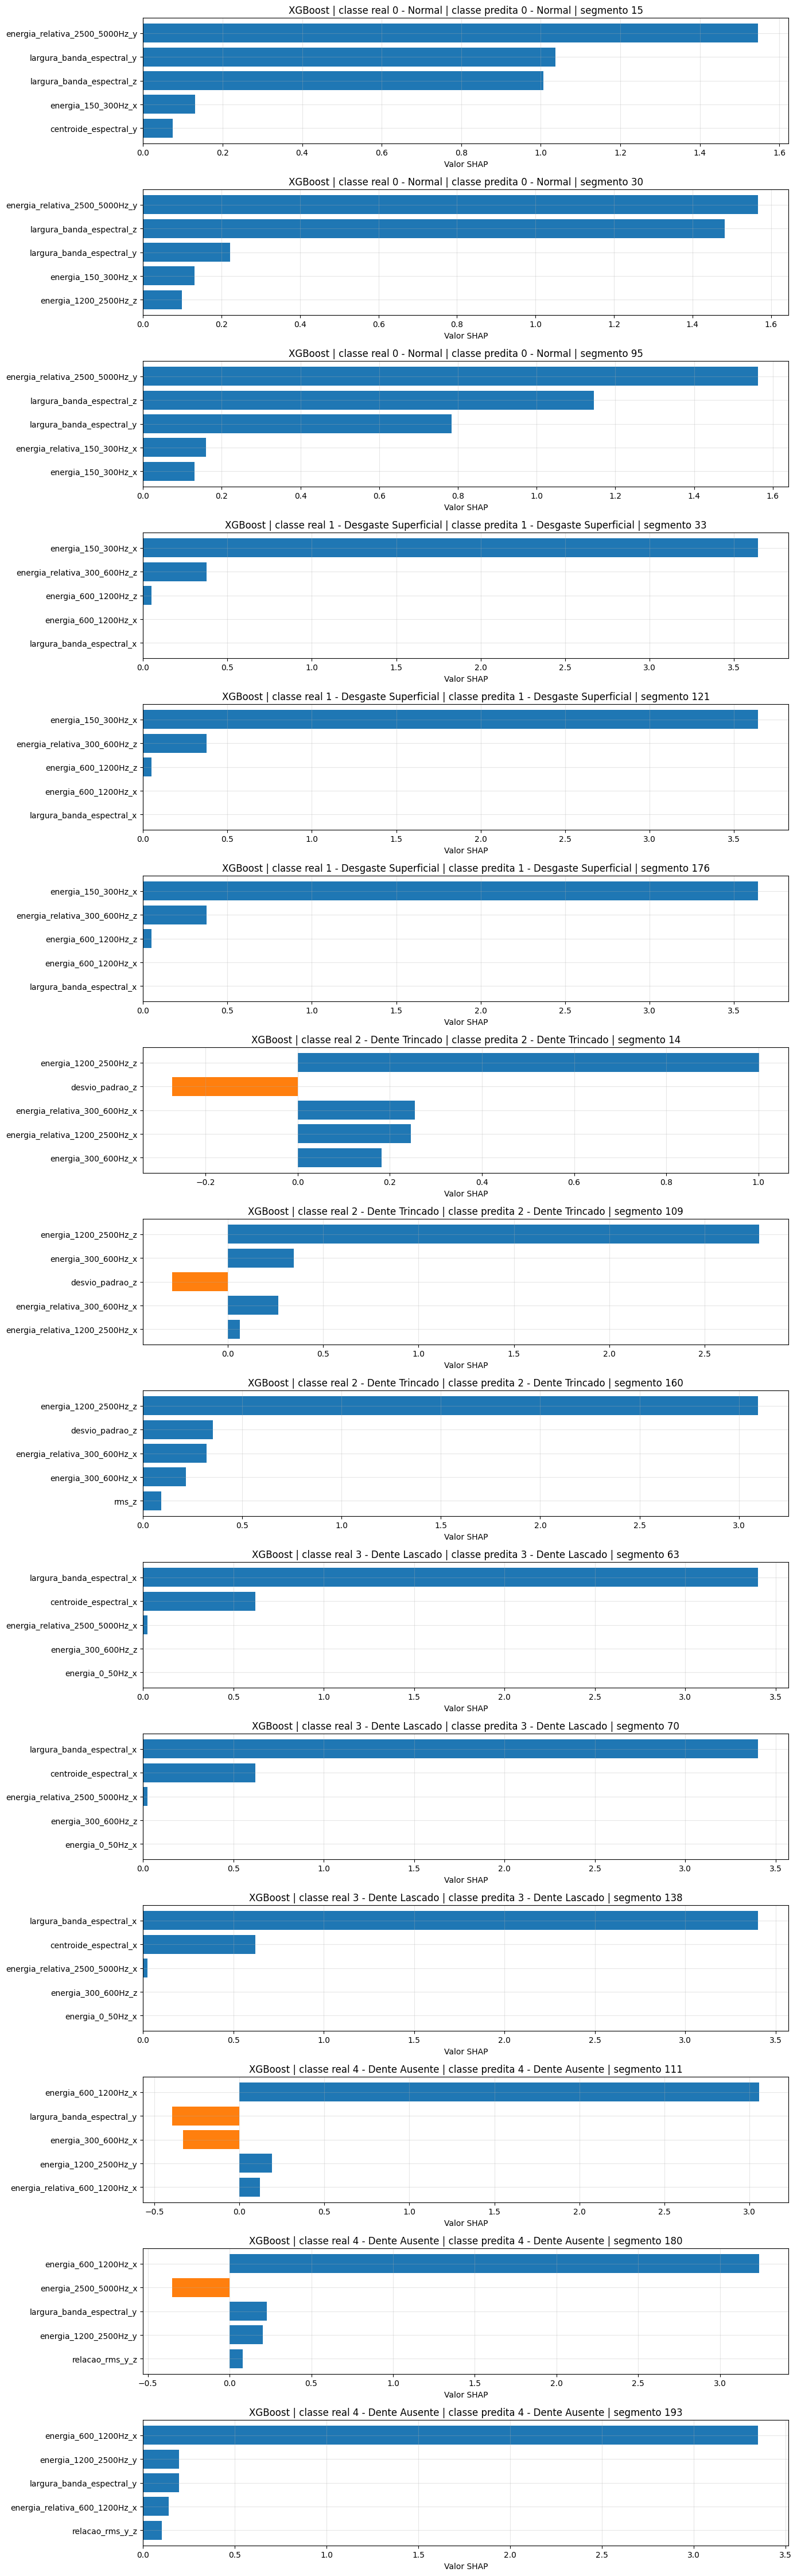

In [345]:
tabela_shap_xgb = tabela_shap_local(xgboost_model, X_explicacao, amostras_explicacao_info, "XGBoost", top_k=5)
print("Top features SHAP - XGBoost")
print(tabela_shap_xgb.to_string(index=False))

fig, axes = plt.subplots(X_explicacao.shape[0], 1, figsize=(14, 3 * X_explicacao.shape[0]), sharex=False)
if X_explicacao.shape[0] == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    tabela_amostra = tabela_shap_xgb[tabela_shap_xgb["amostra_explicacao"] == i].sort_values("impacto_absoluto", ascending=True)
    cores = ["tab:blue" if valor >= 0 else "tab:orange" for valor in tabela_amostra["shap_value"]]
    ax.barh(tabela_amostra["feature"], tabela_amostra["shap_value"], color=cores)
    classe_real = int(tabela_amostra["classe_real"].iloc[0])
    classe_predita = int(tabela_amostra["classe_predita"].iloc[0])
    segmento_id = int(tabela_amostra["segmento_id"].iloc[0])
    ax.set_title(f"XGBoost | classe real {rotulo_classe(classe_real)} | classe predita {rotulo_classe(classe_predita)} | segmento {segmento_id}")
    ax.set_xlabel("Valor SHAP")
    ax.grid(alpha=0.3)

plt.tight_layout()
pasta_imagens = Path("images")
pasta_imagens.mkdir(exist_ok=True)
caminho_shap_xgb = pasta_imagens / "shap_local_xgboost.png"
fig.savefig(caminho_shap_xgb, dpi=300, bbox_inches="tight")
print(f"Grafico salvo em: {caminho_shap_xgb}")
plt.show()


In [346]:
import re

def descrever_feature_tecnica(feature, valor_feature, shap_value):
    eixo_map = {"x": "X", "y": "Y", "z": "Z"}
    direcao = "increased" if shap_value >= 0 else "reduced"
    tendencia = "stronger evidence" if shap_value >= 0 else "weaker evidence"

    match = re.match(r"energia_relativa_(\d+)_(\d+)Hz_([xyz])$", feature)
    if match:
        f_ini, f_fim, eixo = match.groups()
        return f"Relative energy in the {f_ini} to {f_fim} Hz band on axis {eixo_map[eixo]} was {valor_feature:.6f} and {direcao} the evidence for the predicted class, indicating a redistribution of spectral energy in this range."

    match = re.match(r"energia_(\d+)_(\d+)Hz_([xyz])$", feature)
    if match:
        f_ini, f_fim, eixo = match.groups()
        return f"Absolute energy in the {f_ini} to {f_fim} Hz band on axis {eixo_map[eixo]} was {valor_feature:.6f} and {direcao} the evidence for the predicted class, suggesting a vibrational change in this band."

    match = re.match(r"frequencia_dominante_([xyz])$", feature)
    if match:
        eixo = match.group(1)
        return f"The dominant frequency on axis {eixo_map[eixo]} was {valor_feature:.2f} Hz and {direcao} the evidence for the predicted class, indicating vibration concentration at this main component."

    match = re.match(r"amplitude_dominante_([xyz])$", feature)
    if match:
        eixo = match.group(1)
        return f"The dominant amplitude on axis {eixo_map[eixo]} was {valor_feature:.6f} and {direcao} the evidence for the predicted class, showing intensification of the main spectral component."

    match = re.match(r"energia_total_fft_([xyz])$", feature)
    if match:
        eixo = match.group(1)
        return f"Total spectral energy on axis {eixo_map[eixo]} was {valor_feature:.6f} and {direcao} the evidence for the predicted class, reflecting the overall level of vibrational excitation."

    match = re.match(r"centroide_espectral_([xyz])$", feature)
    if match:
        eixo = match.group(1)
        return f"The spectral centroid on axis {eixo_map[eixo]} was {valor_feature:.2f} Hz and {direcao} the evidence for the predicted class, indicating that energy shifted toward higher or lower frequencies."

    match = re.match(r"largura_banda_espectral_([xyz])$", feature)
    if match:
        eixo = match.group(1)
        return f"Spectral bandwidth on axis {eixo_map[eixo]} was {valor_feature:.2f} Hz and {direcao} the evidence for the predicted class, suggesting a broader spread of vibrational content."

    match = re.match(r"media_([xyz])$", feature)
    if match:
        eixo = match.group(1)
        return f"The mean signal level on axis {eixo_map[eixo]} was {valor_feature:.6f} and {direcao} the evidence for the predicted class, indicating a shift in the average signal level."

    match = re.match(r"desvio_padrao_([xyz])$", feature)
    if match:
        eixo = match.group(1)
        return f"The standard deviation on axis {eixo_map[eixo]} was {valor_feature:.6f} and {direcao} the evidence for the predicted class, reflecting overall amplitude variation."

    match = re.match(r"rms_([xyz])$", feature)
    if match:
        eixo = match.group(1)
        return f"The RMS value on axis {eixo_map[eixo]} was {valor_feature:.6f} and {direcao} the evidence for the predicted class, representing the effective vibration level."

    match = re.match(r"media_absoluta_([xyz])$", feature)
    if match:
        eixo = match.group(1)
        return f"The mean absolute value on axis {eixo_map[eixo]} was {valor_feature:.6f} and {direcao} the evidence for the predicted class, indicating an increase or decrease in average vibration severity."

    match = re.match(r"pico_maximo_([xyz])$", feature)
    if match:
        eixo = match.group(1)
        return f"The maximum peak on axis {eixo_map[eixo]} was {valor_feature:.6f} and {direcao} the evidence for the predicted class, pointing to a change in the intensity of the largest signal events."

    match = re.match(r"pico_minimo_([xyz])$", feature)
    if match:
        eixo = match.group(1)
        return f"The minimum peak on axis {eixo_map[eixo]} was {valor_feature:.6f} and {direcao} the evidence for the predicted class, reflecting a change in the negative excursion of the signal."

    match = re.match(r"pico_a_pico_([xyz])$", feature)
    if match:
        eixo = match.group(1)
        return f"The peak-to-peak value on axis {eixo_map[eixo]} was {valor_feature:.6f} and {direcao} the evidence for the predicted class, suggesting variation in total vibration excursion."

    match = re.match(r"fator_crista_([xyz])$", feature)
    if match:
        eixo = match.group(1)
        return f"The crest factor on axis {eixo_map[eixo]} was {valor_feature:.6f} and {direcao} the evidence for the predicted class, which may indicate a more or less impulsive vibration pattern."

    match = re.match(r"relacao_rms_([xyz])_([xyz])$", feature)
    if match:
        eixo_a, eixo_b = match.groups()
        return f"The RMS ratio between axes {eixo_map[eixo_a]} and {eixo_map[eixo_b]} was {valor_feature:.6f} and {direcao} the evidence for the predicted class, indicating asymmetry in vibrational response between directions."

    match = re.match(r"delta_freq_dominante_([xyz])_([xyz])$", feature)
    if match:
        eixo_a, eixo_b = match.groups()
        return f"The difference between the dominant frequencies of axes {eixo_map[eixo_a]} and {eixo_map[eixo_b]} was {valor_feature:.2f} Hz and {direcao} the evidence for the predicted class, indicating spectral misalignment between directions."

    return f"Feature {feature} had a value of {valor_feature:.6f} and {direcao} the evidence for the predicted class, contributing to {tendencia} in the diagnostic decision."

def tabela_shap_texto_tecnico(tabela_shap):
    tabela_texto = tabela_shap.copy()
    tabela_texto["leitura_tecnica"] = tabela_texto.apply(
        lambda row: descrever_feature_tecnica(row["feature"], row["valor_feature"], row["shap_value"]),
        axis=1,
    )
    return tabela_texto

def resumo_tecnico_por_amostra(tabela_texto):
    resumos = []
    for amostra_id in sorted(tabela_texto["amostra_explicacao"].unique()):
        tabela_amostra = tabela_texto[tabela_texto["amostra_explicacao"] == amostra_id].sort_values("rank")
        classe_real = int(tabela_amostra["classe_real"].iloc[0])
        classe_real_nome = tabela_amostra["classe_real_nome"].iloc[0]
        classe_predita = int(tabela_amostra["classe_predita"].iloc[0])
        classe_predita_nome = tabela_amostra["classe_predita_nome"].iloc[0]
        probabilidade = float(tabela_amostra["probabilidade_predita"].iloc[0])
        segmento_id = int(tabela_amostra["segmento_id"].iloc[0])
        tempo_inicial = float(tabela_amostra["tempo_inicial_s"].iloc[0])
        tempo_final = float(tabela_amostra["tempo_final_s"].iloc[0])
        texto_base = " ".join(tabela_amostra["leitura_tecnica"].tolist())
        resumo = (
            f"Sample {amostra_id} | segment {segmento_id} | interval {tempo_inicial:.1f}-{tempo_final:.1f} s | "
            f"true class {classe_real} ({classe_real_nome}) | predicted class {classe_predita} ({classe_predita_nome}) | probability {probabilidade:.3f}. "
            + texto_base
        )
        resumos.append({
            "amostra_explicacao": amostra_id,
            "classe_real": classe_real,
            "classe_real_nome": classe_real_nome,
            "classe_predita": classe_predita,
            "classe_predita_nome": classe_predita_nome,
            "probabilidade_predita": probabilidade,
            "segmento_id": segmento_id,
            "tempo_inicial_s": tempo_inicial,
            "tempo_final_s": tempo_final,
            "resumo_tecnico": resumo,
        })
    return pd.DataFrame(resumos)


In [347]:
tabela_shap_rf_texto = tabela_shap_texto_tecnico(tabela_shap_rf)
resumo_shap_rf_texto = resumo_tecnico_por_amostra(tabela_shap_rf_texto)

print("SHAP table in technical English - RandomForest")
print(tabela_shap_rf_texto[["amostra_explicacao", "classe_real", "classe_predita", "rank", "feature", "shap_value", "leitura_tecnica"]].to_string(index=False))
print()
print("Technical summary by sample - RandomForest")
print(resumo_shap_rf_texto[["amostra_explicacao", "resumo_tecnico"]].to_string(index=False))


SHAP table in technical English - RandomForest
 amostra_explicacao  classe_real  classe_predita  rank                        feature  shap_value                                                                                                                                                                      leitura_tecnica
                  0            0               0     1          energia_2500_5000Hz_y    0.050065                 Absolute energy in the 2500 to 5000 Hz band on axis Y was 0.002481 and increased the evidence for the predicted class, suggesting a vibrational change in this band.
                  0            0               0     2            energia_total_fft_x    0.047430                             Total spectral energy on axis X was 0.017482 and increased the evidence for the predicted class, reflecting the overall level of vibrational excitation.
                  0            0               0     3          energia_2500_5000Hz_x    0.044719                 Ab

In [348]:
tabela_shap_xgb_texto = tabela_shap_texto_tecnico(tabela_shap_xgb)
resumo_shap_xgb_texto = resumo_tecnico_por_amostra(tabela_shap_xgb_texto)

print("SHAP table in technical English - XGBoost")
print(tabela_shap_xgb_texto[["amostra_explicacao", "classe_real", "classe_predita", "rank", "feature", "shap_value", "leitura_tecnica"]].to_string(index=False))
print()
print("Technical summary by sample - XGBoost")
print(resumo_shap_xgb_texto[["amostra_explicacao", "resumo_tecnico"]].to_string(index=False))


SHAP table in technical English - XGBoost
 amostra_explicacao  classe_real  classe_predita  rank                        feature  shap_value                                                                                                                                                                      leitura_tecnica
                  0            0               0     1 energia_relativa_2500_5000Hz_y    1.545812 Relative energy in the 2500 to 5000 Hz band on axis Y was 0.030813 and increased the evidence for the predicted class, indicating a redistribution of spectral energy in this range.
                  0            0               0     2      largura_banda_espectral_y    1.037002                                  Spectral bandwidth on axis Y was 1034.17 Hz and increased the evidence for the predicted class, suggesting a broader spread of vibrational content.
                  0            0               0     3      largura_banda_espectral_z    1.006926                        

In [349]:
import os
from openai import OpenAI

def carregar_openai_api_key():
    api_key = os.getenv("OPENAI_API_KEY")
    if api_key:
        return api_key

    caminho_env = Path(".env")
    if caminho_env.exists():
        conteudo_env = caminho_env.read_text(encoding="utf-8").strip()

        if conteudo_env.startswith("sk-"):
            return conteudo_env.strip().strip(chr(34)).strip(chr(39))

        for linha in conteudo_env.splitlines():
            linha = linha.strip()
            if not linha or linha.startswith("#") or "=" not in linha:
                continue
            chave, valor = linha.split("=", 1)
            if chave.strip() == "OPENAI_API_KEY":
                return valor.strip().strip(chr(34)).strip(chr(39))

    raise ValueError("OPENAI_API_KEY was not found in the environment or in the .env file.")

openai_api_key = carregar_openai_api_key()
openai_model = os.getenv("OPENAI_MODEL", "gpt-5-mini")
cliente_openai = OpenAI(api_key=openai_api_key)

print(f"OpenAI client configured with model: {openai_model}")
print("API key loaded successfully from environment or .env")


OpenAI client configured with model: gpt-5-mini
API key loaded successfully from environment or .env


In [350]:
fonte_shap_llm = "XGBoost"  # choose between "RandomForest" and "XGBoost"
gerar_explicacoes_llm = True
amostra_explicacao_llm = 14

if fonte_shap_llm == "RandomForest":
    tabela_shap_fonte_llm = tabela_shap_rf.copy()
elif fonte_shap_llm == "XGBoost":
    tabela_shap_fonte_llm = tabela_shap_xgb.copy()
else:
    raise ValueError("Invalid fonte_shap_llm. Use RandomForest or XGBoost.")

tabela_llm_amostra = tabela_shap_fonte_llm[
    tabela_shap_fonte_llm["amostra_explicacao"] == amostra_explicacao_llm
].sort_values("rank").copy()

if tabela_llm_amostra.empty:
    raise ValueError("A amostra selecionada para o LLM nao foi encontrada.")

row_llm = tabela_llm_amostra.iloc[0]
top_features_shap_llm = "\n".join(
    tabela_llm_amostra.apply(
        lambda row: f"{int(row['rank'])}. {row['feature']} | feature_value={float(row['valor_feature']):.6f} | shap_value={float(row['shap_value']):.6f} | absolute_impact={float(row['impacto_absoluto']):.6f}",
        axis=1,
    ).tolist()
)

instrucoes_llm = """
You are a predictive maintenance specialist for industrial rotating equipment.
Write the explanation in Brazilian Portuguese.
Use concise and technically precise maintenance language.
Do not mention SHAP, feature importance, AI, or model internals.
Your response must contain exactly the following three section headers, in this exact order:
Interpretação Vibracional:
Interpretação Mecânica:
Ações Recomendadas:
Do not add any other headers.
Base the explanation only on the predicted class, predicted probability, and top SHAP features provided in the prompt.
Be direct and objective.
Do not invent causes, components, frequencies, or inspection findings that are not supported by the provided evidence.
If the evidence is insufficient for a stronger conclusion, say that the indication is inconclusive or suggestive rather than certain.
Do not mention parts or subsystems unless they are justified by the predicted class or by the provided features.
In Interpretação Vibracional, explain the vibration evidence and indicate the most relevant axes and frequency bands.
In Interpretação Mecânica, describe the most likely mechanical interpretation.
In Ações Recomendadas, list the next inspection or maintenance actions.
Keep the full response concise, factual, and grounded in the evidence.
"""

def extrair_uso_tokens_openai(resposta):
    usage = getattr(resposta, "usage", None)

    if usage is None:
        return {
            "input_tokens": None,
            "cached_input_tokens": None,
            "output_tokens": None,
            "total_tokens": None,
        }

    input_tokens = int(getattr(usage, "input_tokens", 0) or 0)
    output_tokens = int(getattr(usage, "output_tokens", 0) or 0)
    total_tokens = int(getattr(usage, "total_tokens", input_tokens + output_tokens) or (input_tokens + output_tokens))

    input_details = getattr(usage, "input_tokens_details", None)
    cached_input_tokens = int(getattr(input_details, "cached_tokens", 0) or 0)

    return {
        "input_tokens": input_tokens,
        "cached_input_tokens": cached_input_tokens,
        "output_tokens": output_tokens,
        "total_tokens": total_tokens,
    }

print(f"LLM explanation source: {fonte_shap_llm}")
print(f"Selected sample: {int(row_llm['amostra_explicacao'])}")
print(f"Predicted class: {int(row_llm['classe_predita'])} - {row_llm['classe_predita_nome']}")
print(f"Predicted probability: {float(row_llm['probabilidade_predita']):.4f}")
print(f"Model configured: {openai_model}")
print(f"OpenAI request enabled: {gerar_explicacoes_llm}")


LLM explanation source: XGBoost
Selected sample: 14
Predicted class: 4 - Dente Ausente
Predicted probability: 0.9975
Model configured: gpt-5-mini
OpenAI request enabled: True


In [351]:
if gerar_explicacoes_llm:
    prompt_usuario = f"""
Generate a maintenance-oriented explanation for the following predictive maintenance case.

Model source: {fonte_shap_llm}
Predicted class: {int(row_llm['classe_predita'])} - {row_llm['classe_predita_nome']}
Predicted probability: {float(row_llm['probabilidade_predita']):.4f}

Top SHAP features:
{top_features_shap_llm}
"""

    resposta = cliente_openai.responses.create(
        model=openai_model,
        instructions=instrucoes_llm,
        input=prompt_usuario,
        max_output_tokens=500,
        reasoning={"effort": "minimal"},
    )

    explicacao_llm_texto = resposta.output_text.strip()
    uso_tokens_llm = extrair_uso_tokens_openai(resposta)
    explicacao_llm_info = {
        "amostra_explicacao": int(row_llm["amostra_explicacao"]),
        "classe_real": int(row_llm["classe_real"]),
        "classe_real_nome": row_llm["classe_real_nome"],
        "classe_predita": int(row_llm["classe_predita"]),
        "classe_predita_nome": row_llm["classe_predita_nome"],
        "probabilidade_predita": float(row_llm["probabilidade_predita"]),
        "segmento_id": int(row_llm["segmento_id"]),
        "tempo_inicial_s": float(row_llm["tempo_inicial_s"]),
        "tempo_final_s": float(row_llm["tempo_final_s"]),
        "fonte_modelo_shap": fonte_shap_llm,
        "input_tokens": uso_tokens_llm["input_tokens"],
        "cached_input_tokens": uso_tokens_llm["cached_input_tokens"],
        "output_tokens": uso_tokens_llm["output_tokens"],
        "total_tokens": uso_tokens_llm["total_tokens"],
        "explicacao_llm": explicacao_llm_texto,
    }
    explicacoes_llm = pd.DataFrame([explicacao_llm_info])

    print(f"Amostra explicada: {explicacao_llm_info['amostra_explicacao']}")
    print(f"Classe predita: {explicacao_llm_info['classe_predita']} - {explicacao_llm_info['classe_predita_nome']}")
    print(f"Probabilidade: {explicacao_llm_info['probabilidade_predita']:.4f}")
    print(f"Tokens de entrada: {explicacao_llm_info['input_tokens']}")
    print(f"Tokens de entrada em cache: {explicacao_llm_info['cached_input_tokens']}")
    print(f"Tokens de saida: {explicacao_llm_info['output_tokens']}")
    print(f"Tokens totais: {explicacao_llm_info['total_tokens']}")
    print()
    print(explicacao_llm_texto)
else:
    explicacoes_llm = pd.DataFrame()
    explicacao_llm_texto = ""
    print("OpenAI API call skipped. Set gerar_explicacoes_llm = True to generate the explanations.")


Amostra explicada: 14
Classe predita: 4 - Dente Ausente
Probabilidade: 0.9975
Tokens de entrada: 477
Tokens de entrada em cache: 0
Tokens de saida: 415
Tokens totais: 892

Interpretação Vibracional:
A evidência vibracional indica aumento de energia no intervalo 600–1200 Hz principalmente no eixo X (energia_600_1200Hz_x com impacto dominante). Também há contribuição menor de energia em 1200–2500 Hz no eixo Y e aumento da largura de banda espectral no eixo Y. Eixos mais relevantes: X (principal) e Y (secundário). O padrão é compatível com pulsos repetitivos de alta energia em banda media (600–1200 Hz) no X, com dispersão espectral aumentada no Y.

Interpretação Mecânica:
A predição classifica como "Dente Ausente" com probabilidade muito alta (0,9975). O sinal forte na banda 600–1200 Hz no eixo X é sugestivo de impacto ou perda periódica de contato/engrenamento em rotação que gera impulsos na faixa média de frequência. A contribuição no eixo Y e a maior largura de banda no Y indicam que o